# Skin Lesion Classification on HAM10000

End-to-end pipeline:

1. Three-way split (train / val / test) stratified by lesion identity.
2. Architecture comparison across four pretrained backbones.
3. Final training on the winner's upgraded variant with MixUp + EMA.
4. Temperature scaling on the validation set.
5. Held-out test-set evaluation of the calibrated model.

The validation set drives all model-selection and calibration decisions; the
test set is used **once** at the end for the reported numbers.

## Setup

In [1]:
import os
import io
import json
import random
import base64
import shutil
import glob

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib import cm
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torch.optim.swa_utils import AveragedModel, get_ema_multi_avg_fn
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, classification_report,
    balanced_accuracy_score, recall_score, precision_score, f1_score,
)
from sklearn.preprocessing import label_binarize
from scipy.stats import chi2_contingency
from tqdm import tqdm
from google.colab import drive

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Data loading

Mount Drive, copy the dataset onto local disk for faster I/O, and load the metadata.

In [4]:
drive.mount('/content/drive')

DRIVE_DATA = '/content/drive/MyDrive/skin_cancer_detection/data'
LOCAL_DATA = '/content/data'

# Copy the dataset onto local Colab disk so the DataLoader workers can read
# images without going through Drive's mounted-FS bottleneck. The guard
# verifies file counts match — a folder-existence check alone misses
# half-copied directories from an interrupted run.
expected = sum(1 for _ in glob.iglob(f'{DRIVE_DATA}/**/*.jpg', recursive=True))
actual = sum(1 for _ in glob.iglob(f'{LOCAL_DATA}/**/*.jpg', recursive=True)) if os.path.exists(LOCAL_DATA) else 0
if actual < expected:
    print(f'Copy incomplete ({actual}/{expected}). Re-copying...')
    if os.path.exists(LOCAL_DATA):
        shutil.rmtree(LOCAL_DATA)

    os.makedirs(LOCAL_DATA, exist_ok=True)
    files_to_copy = []
    for root, _, files in os.walk(DRIVE_DATA):
        for f in files:
            files_to_copy.append(os.path.join(root, f))

    for src in tqdm(files_to_copy, desc="Copying files to local disk"):
        dst = os.path.join(LOCAL_DATA, os.path.relpath(src, DRIVE_DATA))
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        shutil.copy2(src, dst)

DATA_PATH = LOCAL_DATA

metadata_path = os.path.join(DATA_PATH, 'HAM10000_metadata.csv')
df = pd.read_csv(metadata_path)

print(f'Metadata shape:        {df.shape}')
print(f'Unique lesion_ids:     {df["lesion_id"].nunique()}')
print(f'Unique image_ids:      {df["image_id"].nunique()}')
print(f'Missing values:\n{df.isnull().sum()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copy incomplete (55/10015). Re-copying...


Copying files to local disk: 100%|██████████| 10020/10020 [02:27<00:00, 67.72it/s]

Metadata shape:        (10015, 7)
Unique lesion_ids:     7470
Unique image_ids:      10015
Missing values:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64


Images with resolved paths: 10015 / 10015


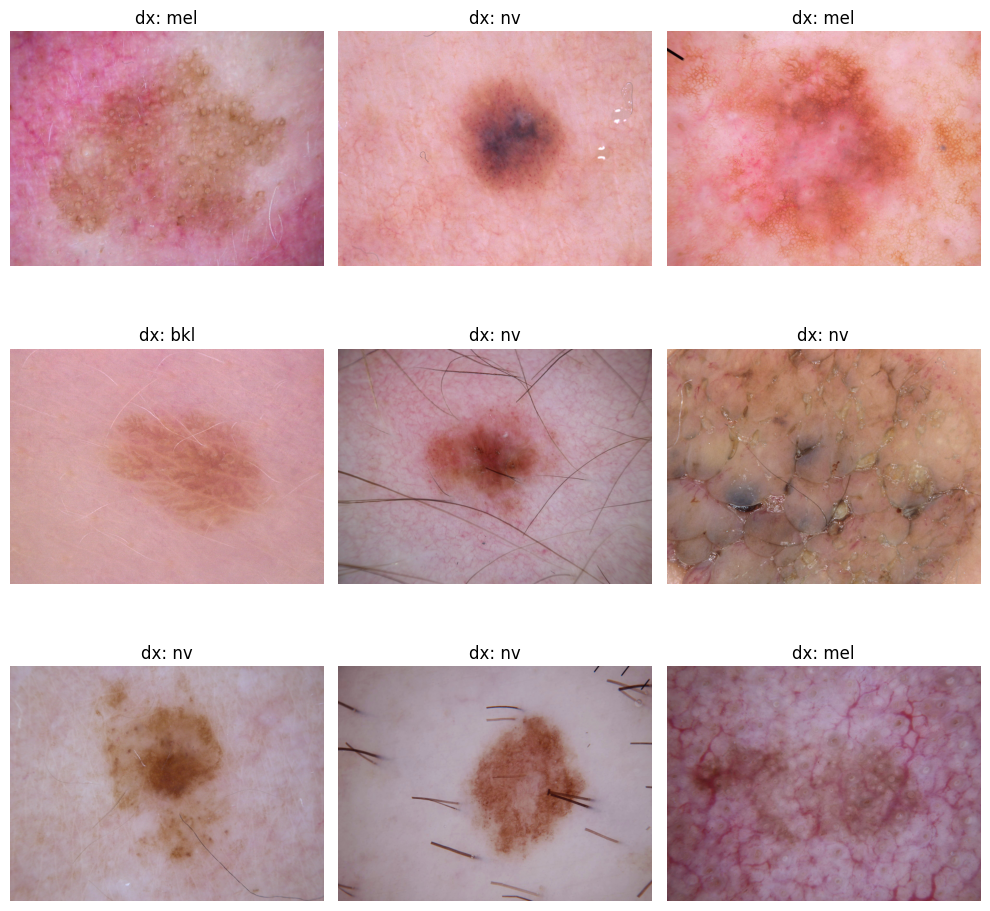

In [5]:
img_dir_1 = os.path.join(DATA_PATH, 'HAM10000_images_part_1')
img_dir_2 = os.path.join(DATA_PATH, 'HAM10000_images_part_2')


def resolve_image_path(image_id):
    """Return the absolute path of an HAM10000 image, or None if not found."""
    for d in (img_dir_1, img_dir_2):
        p = os.path.join(d, image_id + '.jpg')
        if os.path.exists(p):
            return p
    return None


df['image_path'] = df['image_id'].apply(resolve_image_path)
df_with_images = df.dropna(subset=['image_path']).copy()
print(f'Images with resolved paths: {len(df_with_images)} / {len(df)}')

# Display a 3x3 sample to spot-check the data
plt.figure(figsize=(10, 10))
sample_df = df_with_images.sample(9, random_state=42)
for i, (_, row) in enumerate(sample_df.iterrows()):
    plt.subplot(3, 3, i + 1)
    plt.imshow(Image.open(row['image_path']))
    plt.title(f"dx: {row['dx']}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Exploratory data analysis

Class balance, demographics, anatomical localization, and a Cramér's V
association matrix in place of Pearson correlation (the lesion class and
localization are nominal categoricals, for which Pearson is meaningless).

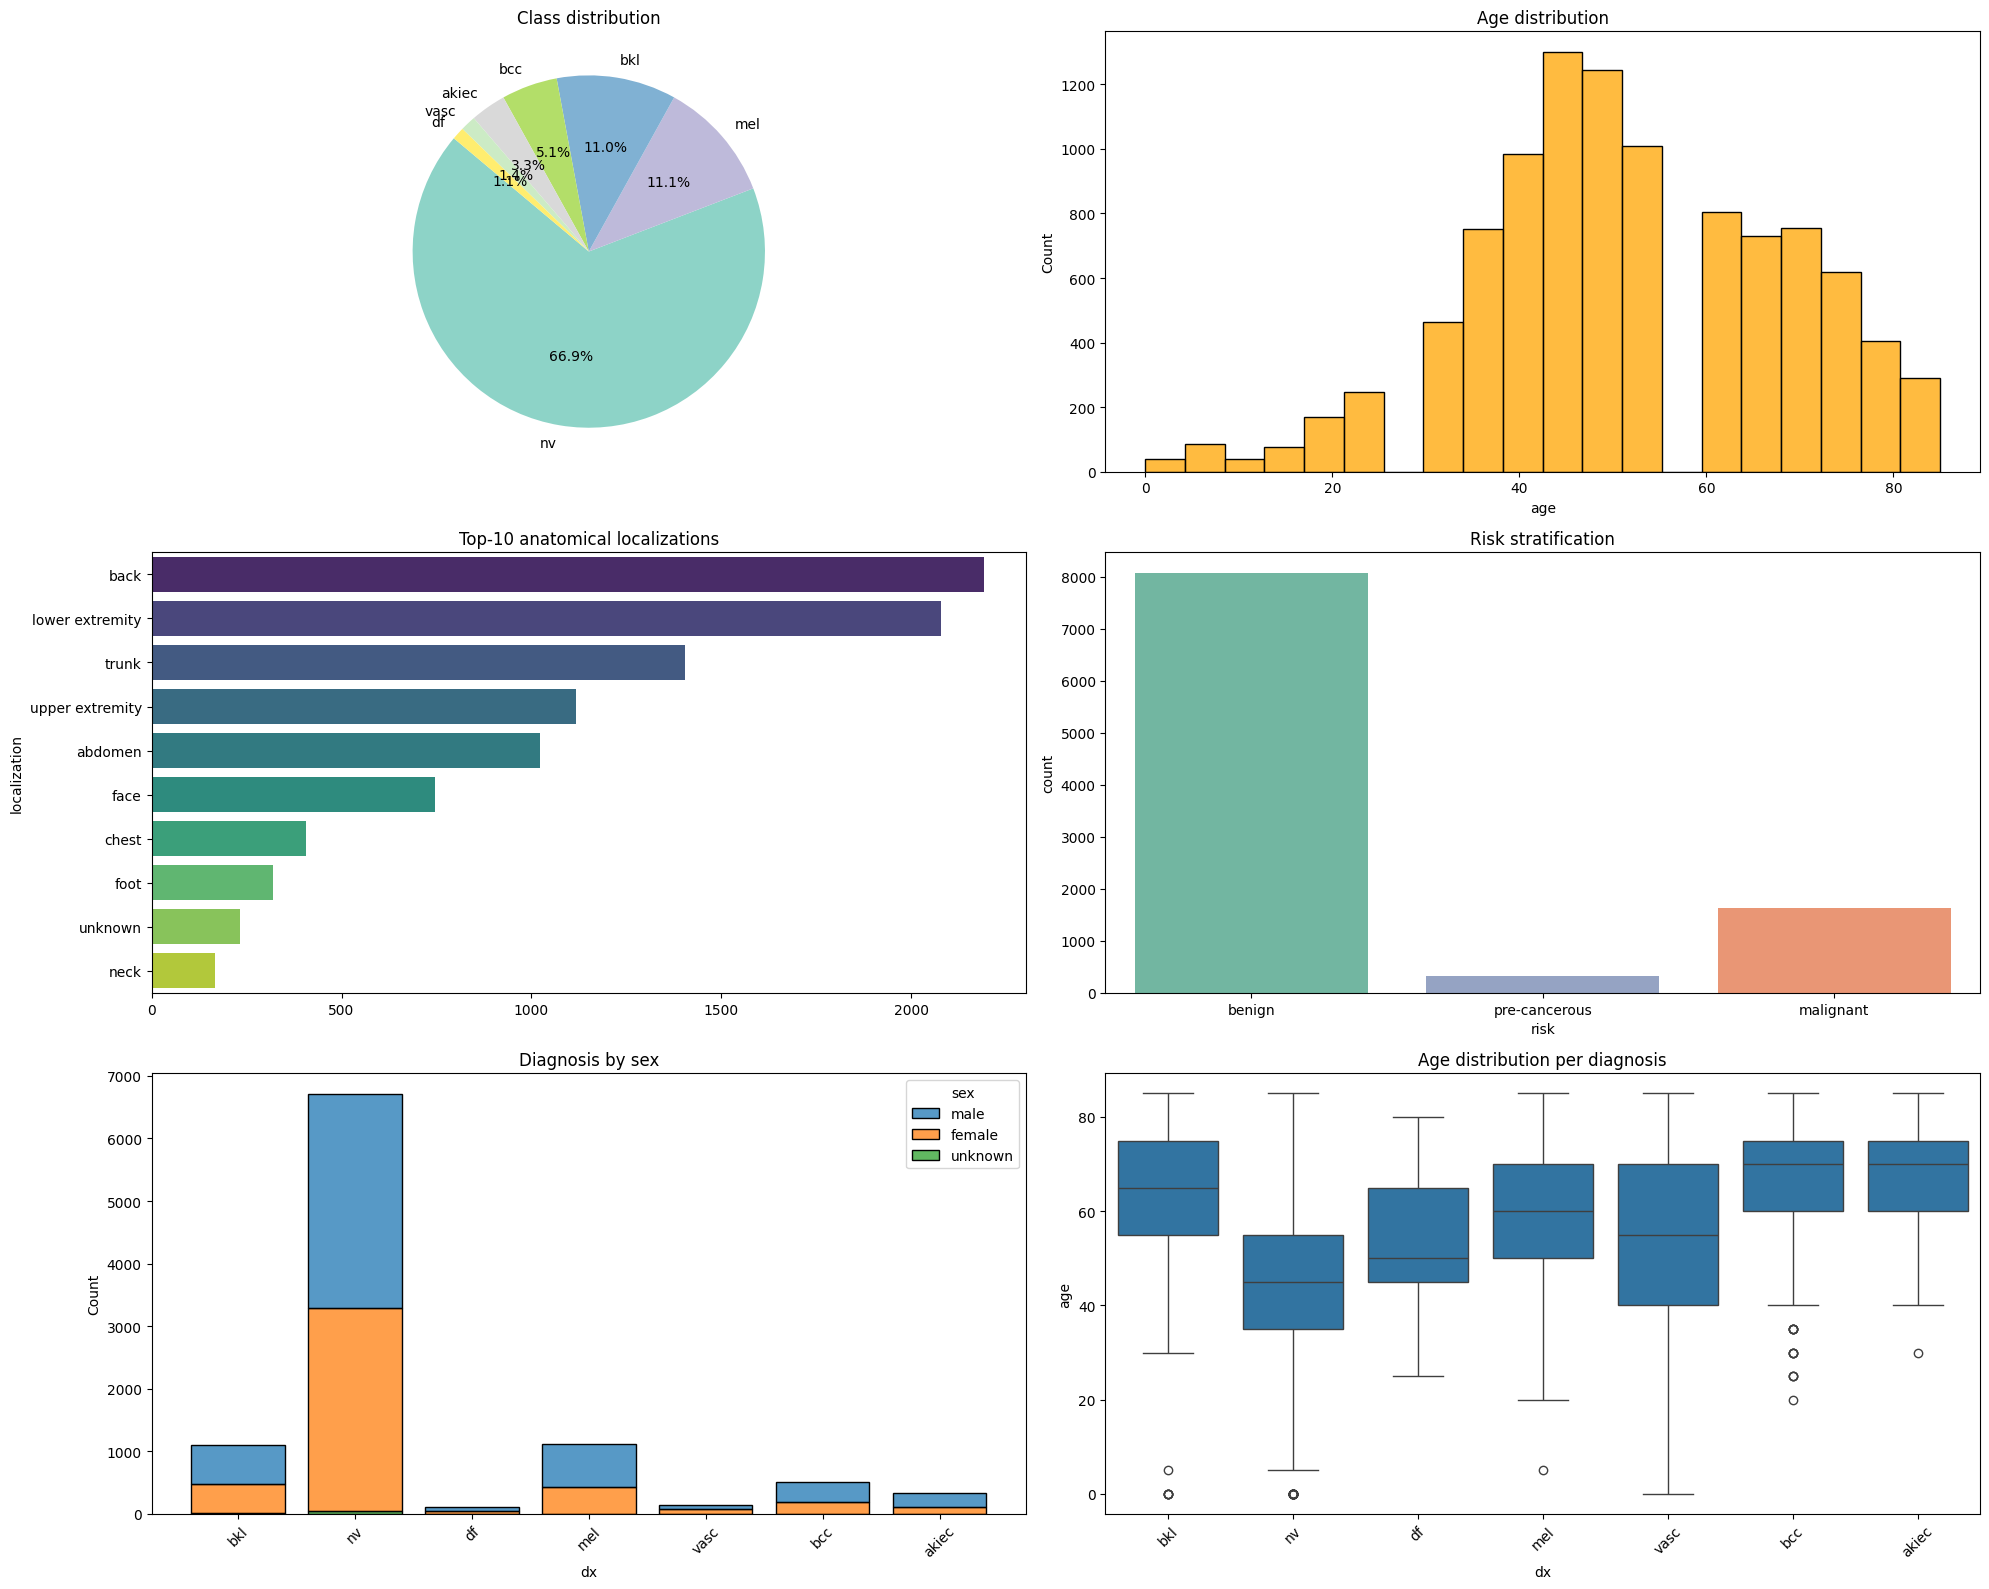

In [6]:
# Impute missing age values with the median over images we kept.
df_with_images['age'] = df_with_images['age'].fillna(df_with_images['age'].median())

plt.figure(figsize=(20, 16))

# Class distribution
plt.subplot(3, 2, 1)
counts = df_with_images['dx'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140,
        colors=plt.cm.Set3(np.linspace(0, 1, len(counts))))
plt.title('Class distribution')

# Age distribution
plt.subplot(3, 2, 2)
sns.histplot(df_with_images['age'], bins=20, kde=False, color='orange')
plt.title('Age distribution')

# Top-10 lesion localizations
plt.subplot(3, 2, 3)
top10 = df_with_images['localization'].value_counts().head(10)
sns.barplot(y=top10.index, x=top10.values, hue=top10.index,
            palette='viridis', legend=False)
plt.title('Top-10 anatomical localizations')

# Risk stratification
plt.subplot(3, 2, 4)
RISK_MAP = {
    'nv': 'benign', 'bkl': 'benign', 'df': 'benign', 'vasc': 'benign',
    'akiec': 'pre-cancerous',
    'bcc': 'malignant', 'mel': 'malignant',
}
df_with_images['risk'] = df_with_images['dx'].map(RISK_MAP)
sns.countplot(data=df_with_images, x='risk',
              order=['benign', 'pre-cancerous', 'malignant'],
              hue='risk', palette='Set2', legend=False)
plt.title('Risk stratification')

# Diagnosis split by sex
plt.subplot(3, 2, 5)
sns.histplot(data=df_with_images, x='dx', hue='sex',
             multiple='stack', shrink=0.8)
plt.title('Diagnosis by sex')
plt.xticks(rotation=45)

# Age distribution per diagnosis
plt.subplot(3, 2, 6)
sns.boxplot(data=df_with_images, x='dx', y='age')
plt.title('Age distribution per diagnosis')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

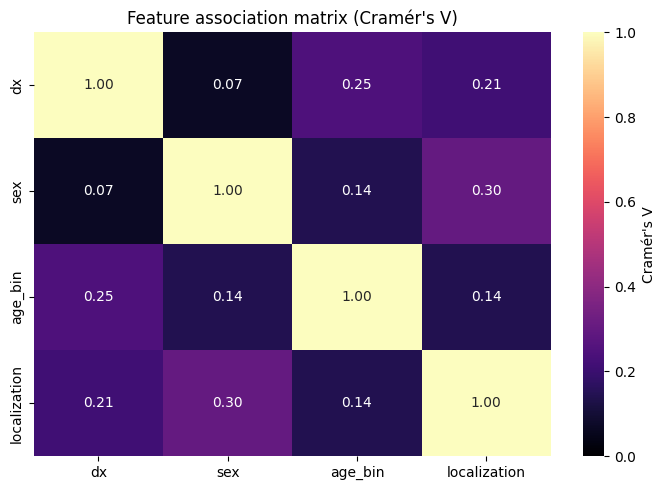

In [7]:
def cramers_v(x, y):
    """Compute bias-corrected Cramér's V between two categorical variables.

    Uses the Bergsma & Wicher (2013) correction so the statistic stays in
    [0, 1] even for small samples.

    Args:
        x: First categorical series.
        y: Second categorical series.

    Returns:
        Cramér's V coefficient, or NaN if either input is constant.
    """
    table = pd.crosstab(x, y)
    if table.size == 0 or min(table.shape) < 2:
        return float('nan')
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.values.sum()
    r, k = table.shape
    phi2 = chi2 / n
    phi2_corr = max(0.0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(k_corr - 1, r_corr - 1)
    return np.sqrt(phi2_corr / denom) if denom > 0 else float('nan')


# Bucket age so it can participate in a chi-square-based association measure.
age_binned = pd.cut(df_with_images['age'], bins=[0, 30, 45, 60, 75, 100],
                    include_lowest=True)
cols = {
    'dx':           df_with_images['dx'],
    'sex':          df_with_images['sex'],
    'age_bin':      age_binned,
    'localization': df_with_images['localization'],
}
names = list(cols.keys())
matrix = np.eye(len(names))
for i, a in enumerate(names):
    for j, b in enumerate(names):
        if i != j:
            matrix[i, j] = cramers_v(cols[a], cols[b])

plt.figure(figsize=(7, 5))
sns.heatmap(pd.DataFrame(matrix, index=names, columns=names),
            annot=True, cmap='magma', fmt='.2f', vmin=0, vmax=1,
            cbar_kws={'label': "Cramér's V"})
plt.title("Feature association matrix (Cramér's V)")
plt.tight_layout()
plt.show()

## Class encoding

A fixed integer mapping for the seven HAM10000 classes. The melanoma class
is index 1 throughout the notebook — early-stopping, calibration and the
post-hoc reports all refer to it by that index.

In [8]:
CLASS_MAP = {
    'nv':    0,
    'mel':   1,
    'bkl':   2,
    'bcc':   3,
    'akiec': 4,
    'vasc':  5,
    'df':    6,
}
df_with_images['label'] = df_with_images['dx'].map(CLASS_MAP)

display(CLASS_MAP)

{'nv': 0, 'mel': 1, 'bkl': 2, 'bcc': 3, 'akiec': 4, 'vasc': 5, 'df': 6}

## Datasets and transforms

Two dataset classes: `MNIST_HAM_Dataset` for training (transform fixed at
construction) and `TTADataset` for test-time augmentation (transform mutable
per pass; built fresh for each pass when used with multi-worker loaders).

In [9]:
class MNIST_HAM_Dataset(Dataset):
    """Dataset wrapping HAM10000 image paths with a fixed transform.

    Used for training and any single-pass validation. Positional indexing via
    `iloc` is required — the calling code relies on stable position-to-image
    ordering for both DataLoader iteration and TTA accumulator alignment.
    """

    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        img_path = self.df.iloc[index]['image_path']
        image = cv2.imread(img_path)
        if image is None:
            raise RuntimeError(
                f'cv2.imread returned None for {img_path!r} (row {index}). '
                f'File missing or corrupt.'
            )
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label = torch.tensor(int(self.df.iloc[index]['label']))
        if self.transform is not None:
            image = self.transform(image)
        return image, label


class TTADataset(Dataset):
    """Validation dataset with a mutable transform attribute.

    Used by `tta_validate`, which builds a fresh `TTADataset` per pass so each
    DataLoader receives a stable, immutable transform (forked workers don't
    see post-fork mutation).
    """

    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        img_path = self.df.iloc[index]['image_path']
        image = cv2.imread(img_path)
        if image is None:
            raise RuntimeError(
                f'cv2.imread returned None for {img_path!r} (row {index}). '
                f'File missing or corrupt.'
            )
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label = int(self.df.iloc[index]['label'])
        if self.transform is not None:
            image = self.transform(image)
        return image, label

In [10]:
_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]


def get_train_transforms(img_size):
    """Augmentation pipeline applied to training images.

    Aggressive geometric and color jitter — skin lesions have no canonical
    orientation, so 90° rotation and both flips are safe; color jitter is
    bounded to preserve diagnostic colour information.
    """
    return transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomResizedCrop(img_size, scale=(0.6, 1.0)),
        transforms.RandomAffine(degrees=90, shear=(-15, 15), scale=(0.85, 1.15)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.3, contrast=0.3,
                               saturation=0.3, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(_MEAN, _STD),
    ])


def get_val_transforms(img_size):
    """Deterministic center-crop transform for clean validation passes."""
    return transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize(int(img_size * 1.07)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(_MEAN, _STD),
    ])


def get_tta_transforms(img_size):
    """Light augmentation pipeline used by TTA at validation/test time.

    Lighter than the training pipeline — we want realistic test-time
    variation, not extreme distortions that could change the prediction.
    """
    return transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomResizedCrop(img_size, scale=(0.75, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomAffine(degrees=45, shear=(-10, 10)),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
        transforms.ToTensor(),
        transforms.Normalize(_MEAN, _STD),
    ])


# Input resolutions per architecture (must match the values used at training).
IMG_SIZE = {
    'resnet50':         224,
    'vgg16':            224,
    'densenet169':      224,
    'efficientnet_b2':  260,
    'resnet152':         224,
    'densenet201':       224,
    'efficientnet_v2_s': 384,
    'convnext_tiny':     224,
}

## Three-way split (train / val / test)

Splits are performed at the **lesion identity** level — HAM10000 contains
multiple images of the same physical lesion, so a per-image split would
leak near-duplicates between subsets. We split once into train+val versus
test (15 % test), then split the remainder into train versus val (~18 % of
remainder ≈ 15 % of total).

- **train** → parameter optimisation.
- **val** → best-epoch selection, calibration, threshold tuning.
- **test** → reported **once** at the end. Never used for any model choice.

In [11]:
# One label per lesion (consistency assertion guards against silent breakage
# if HAM10000 ever ships a lesion with mixed dx labels).
lesion_labels = df_with_images.groupby('lesion_id')['label'].first()
assert (df_with_images.groupby('lesion_id')['label'].nunique() == 1).all(), \
    'A lesion_id has multiple distinct dx labels — stratification target is unreliable.'

# Step 1: train+val vs test
trainval_lesions, test_lesions = train_test_split(
    lesion_labels.index,
    test_size=0.15,
    random_state=42,
    stratify=lesion_labels.values,
)

# Step 2: train vs val from the remainder
trainval_labels = lesion_labels.loc[trainval_lesions]
train_lesions, val_lesions = train_test_split(
    trainval_labels.index,
    test_size=0.176,        # 0.176 of 0.85 ≈ 0.15 of total
    random_state=42,
    stratify=trainval_labels.values,
)

train_df = df_with_images[df_with_images['lesion_id'].isin(train_lesions)].reset_index(drop=True)
val_df   = df_with_images[df_with_images['lesion_id'].isin(val_lesions)].reset_index(drop=True)
test_df  = df_with_images[df_with_images['lesion_id'].isin(test_lesions)].reset_index(drop=True)

total = len(df_with_images)
print(f'train : {len(train_df):>5} images ({100*len(train_df)/total:.1f}%)')
print(f'val   : {len(val_df):>5} images ({100*len(val_df)/total:.1f}%)')
print(f'test  : {len(test_df):>5} images ({100*len(test_df)/total:.1f}%)')

# Class balance per split — sanity check that stratification worked
print()
print(pd.DataFrame({
    'train': train_df['dx'].value_counts(),
    'val':   val_df['dx'].value_counts(),
    'test':  test_df['dx'].value_counts(),
}).fillna(0).astype(int))

train :  7022 images (70.1%)
val   :  1477 images (14.7%)
test  :  1516 images (15.1%)

       train  val  test
dx                     
akiec    235   45    47
bcc      360   76    78
bkl      778  159   162
df        77   18    20
mel      770  175   168
nv      4703  982  1020
vasc      99   22    21


In [12]:
# WeightedRandomSampler — equalises class exposure per epoch on the TRAIN
# split only. Val and test are never resampled and are evaluated under the
# natural class distribution.
num_classes = len(CLASS_MAP)
class_counts = np.array(
    [(train_df['label'] == c).sum() for c in range(num_classes)],
    dtype=np.int64,
)
assert (class_counts > 0).all(), \
    f'Some classes have zero training samples: {class_counts}'

sample_class_weight = 1.0 / class_counts.astype(np.float64)
sample_weights = sample_class_weight[train_df['label'].values]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)
print(f'Per-class training counts:    {dict(zip(CLASS_MAP, class_counts))}')
print(f'Sampler num_samples per epoch: {len(sample_weights)}')

Per-class training counts:    {'nv': np.int64(4703), 'mel': np.int64(770), 'bkl': np.int64(778), 'bcc': np.int64(360), 'akiec': np.int64(235), 'vasc': np.int64(99), 'df': np.int64(77)}
Sampler num_samples per epoch: 7022


## Architectures

Two pools of architectures:

- **Comparison pool** — four medium-sized pretrained backbones tested under
  identical recipes to choose a winner.
- **Upgrade pool** — for each comparison entry, the larger / more modern
  variant from the same family, used for the final training run on the
  selected winner.

In [13]:
def initialize_model(model_name, num_classes=7):
    """Construct one of the four comparison-pool architectures with a small
    custom classification head.

    Each head is calibrated to the backbone's output dimensionality:
    BatchNorm1d → ReLU → Dropout for ResNet/DenseNet, a Dropout-only bottleneck
    for VGG (which already has heavy dropout in its classifier), and a
    Dropout-SiLU-Dropout stack for EfficientNet (matching the V2-style head).

    Args:
        model_name: One of 'resnet50', 'vgg16', 'densenet169', 'efficientnet_b2'.
        num_classes: Number of output classes for the final Linear.

    Returns:
        nn.Module on the appropriate device, with weights initialised from
        ImageNet pretraining and a freshly-initialised classification head.
    """
    if model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        model.fc = nn.Sequential(
            nn.Linear(model.fc.in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),
            nn.Linear(512, num_classes),
        )

    elif model_name == 'vgg16':
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        # VGG already has Dropout(0.5) upstream → no BatchNorm needed here.
        model.classifier[6] = nn.Sequential(
            nn.Linear(model.classifier[6].in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes),
        )

    elif model_name == 'densenet169':
        model = models.densenet169(weights=models.DenseNet169_Weights.IMAGENET1K_V1)
        model.classifier = nn.Sequential(
            nn.Linear(model.classifier.in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),
            nn.Linear(256, num_classes),
        )

    elif model_name == 'efficientnet_b2':
        model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1)
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.3, inplace=True),
            nn.Linear(model.classifier[1].in_features, 256),
            nn.SiLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes),
        )

    else:
        raise ValueError(f'Unknown model_name: {model_name!r}')

    return model.to(device)

In [14]:
def _build_efficientnet_v2_s(num_classes):
    """Build EfficientNetV2-S with bumped stochastic depth for fine-tuning."""
    model = models.efficientnet_v2_s(
        weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1,
        stochastic_depth_prob=0.3,
    )
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(model.classifier[1].in_features, 256),
        nn.SiLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes),
    )
    return model.to(device)


def _build_resnet152(num_classes):
    """Build ResNet-152 with the same head structure as the ResNet-50 baseline."""
    model = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V1)
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.4),
        nn.Linear(512, num_classes),
    )
    return model.to(device)


def _build_densenet201(num_classes):
    """Build DenseNet-201 with the same head structure as the DenseNet-169 baseline."""
    model = models.densenet201(weights=models.DenseNet201_Weights.IMAGENET1K_V1)
    model.classifier = nn.Sequential(
        nn.Linear(model.classifier.in_features, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.4),
        nn.Linear(256, num_classes),
    )
    return model.to(device)


def _build_convnext_tiny(num_classes):
    """Build ConvNeXt-Tiny — the modernised pure-ConvNet successor to VGG."""
    model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
    # ConvNeXt classifier is Sequential(LayerNorm2d, Flatten, Linear).
    # Only the final Linear is replaced with our bottleneck.
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.GELU(),
        nn.Dropout(p=0.4),
        nn.Linear(256, num_classes),
    )
    return model.to(device)


# Per-architecture upgrade plan. For each comparison entry, the upgrade is a
# larger or more modern variant from the same architectural family. The
# `head_module_fn` is used by `train_upgraded_winner` to identify the head
# module for differential learning rates in Phase 2.
UPGRADE_MAP = {
    'efficientnet_b2': {
        'upgrade_name': 'efficientnet_v2_s',
        'img_size': 384,
        'init_fn': _build_efficientnet_v2_s,
        'head_module_fn': lambda m: m.classifier,
        'rationale': 'Same compound-scaling philosophy with the improved V2 training recipe.',
    },
    'resnet50': {
        'upgrade_name': 'resnet152',
        'img_size': 224,
        'init_fn': _build_resnet152,
        'head_module_fn': lambda m: m.fc,
        'rationale': 'Same residual blocks, three times deeper.',
    },
    'densenet169': {
        'upgrade_name': 'densenet201',
        'img_size': 224,
        'init_fn': _build_densenet201,
        'head_module_fn': lambda m: m.classifier,
        'rationale': 'Same dense-connection design with more layers.',
    },
    'vgg16': {
        'upgrade_name': 'convnext_tiny',
        'img_size': 224,
        'init_fn': _build_convnext_tiny,
        'head_module_fn': lambda m: m.classifier[2],
        'rationale': 'Pure-ConvNet successor with a modernised training recipe.',
    },
}

## Training utilities

Small helpers shared between the two training functions: BatchNorm freezing,
head-parameter accessor, MixUp helper, TTA validation, and model checkpointing.

In [15]:
def set_bn_eval(model):
    """Force all BatchNorm layers into eval mode.

    Used in Phase 2 fine-tuning to prevent backbone BatchNorm2d from updating
    its running statistics on the class-rebalanced batches produced by
    `WeightedRandomSampler` (which would create a distribution mismatch with
    the natural class frequencies at inference time). Head BatchNorm1d is
    frozen for the same reason — small bottlenecks are batch-noise sensitive.
    """
    for module in model.modules():
        if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d)):
            module.eval()


def get_head_params(model, model_name):
    """Return an iterator over the parameters of the classification head.

    Used by Phase 1 to optimise only the head while the backbone is frozen.

    Args:
        model: The constructed nn.Module.
        model_name: Architecture name (must be one of the comparison pool).
    """
    if model_name == 'resnet50':
        return model.fc.parameters()
    if model_name == 'densenet169':
        return model.classifier.parameters()
    if model_name == 'efficientnet_b2':
        return model.classifier.parameters()
    if model_name == 'vgg16':
        return model.classifier[6].parameters()
    raise ValueError(f'Unknown model_name: {model_name!r}')


def mixup_batch(images, labels, alpha=0.2):
    """Apply MixUp to a single batch.

    Returns the mixed images and the two label tensors plus the mixing ratio,
    so the caller can compute the loss as
    `lam * CE(out, y_a) + (1 - lam) * CE(out, y_b)`, which is mathematically
    equivalent to CE on the mixed soft target and composes cleanly with the
    label-smoothed criterion.

    Args:
        images: (B, C, H, W) tensor on device.
        labels: (B,) tensor on device.
        alpha: Beta-distribution shape parameter (Beta(alpha, alpha)).

    Returns:
        Tuple of (mixed_images, labels_a, labels_b, lam).
    """
    lam = float(np.random.beta(alpha, alpha)) if alpha > 0 else 1.0
    idx = torch.randperm(images.size(0), device=images.device)
    mixed = lam * images + (1.0 - lam) * images[idx]
    return mixed, labels, labels[idx], lam


def save_model_to_drive(state_dict, model_name, subdir='models'):
    """Save a model's state_dict under the project's Drive folder."""
    save_dir = f'/content/drive/MyDrive/skin_cancer_detection/{subdir}'
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f'best_{model_name}.pth')
    torch.save(state_dict, save_path)
    print(f'[SUCCESS] {model_name} parameters saved to: {save_path}')

In [16]:
@torch.no_grad()
def tta_validate(model, df, img_size, criterion,
                 n_augmented=4, batch_size=64, use_amp=True,
                 amp_dtype=torch.float16, num_workers=4, temperature=1.0,
                 desc='TTA Val'):
    """Evaluate a model with test-time augmentation.

    Runs one clean center-crop pass followed by `n_augmented` augmented
    passes, all with the same model parameters. Softmax outputs are averaged
    across the (1 + n_augmented) passes. The clean pass also produces the
    cross-entropy loss reported for early stopping.

    The dataset is rebuilt per pass with the desired transform fixed at
    construction — this keeps multi-worker DataLoaders safe (forked workers
    do not see post-fork mutation of `dataset.transform`).

    Args:
        model: nn.Module in eval mode (the function calls .eval() itself).
        df: pandas DataFrame describing the images to evaluate.
        img_size: Input resolution used by the clean and TTA transforms.
        criterion: Loss criterion (used for the val_loss return value).
        n_augmented: Number of augmented passes (in addition to the clean one).
        batch_size: Batch size for inference.
        use_amp: Whether to run forward passes under autocast.
        amp_dtype: Autocast dtype — bfloat16 on Ampere+, float16 on Turing.
        num_workers: DataLoader workers per pass (set to 0 for full
            reproducibility; workers have independent RNG states).
        temperature: Calibration temperature; logits are divided by it
            before softmax (defaults to 1.0 = no calibration).
        desc: Description string prefix for the tqdm progress bar.

    Returns:
        Tuple of (val_loss, labels, predictions, averaged_probs).
    """
    model.eval()
    clean_t = get_val_transforms(img_size)
    tta_t = get_tta_transforms(img_size)

    num_samples = len(df)
    num_classes = 7
    prob_sum = np.zeros((num_samples, num_classes), dtype=np.float64)
    labels_out = np.zeros(num_samples, dtype=np.int64)
    val_loss_sum = 0.0

    # Clean pass — also produces the validation loss.
    clean_ds = TTADataset(df, transform=clean_t)
    clean_loader = DataLoader(clean_ds, batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    idx = 0
    for images, labels in tqdm(clean_loader, desc=f'{desc} [clean]', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=use_amp, dtype=amp_dtype):
            logits = model(images)
            loss = criterion(logits, labels)
            probs = F.softmax(logits / temperature, dim=1)
        val_loss_sum += loss.item() * images.size(0)
        bs = probs.size(0)
        prob_sum[idx:idx + bs] += probs.cpu().numpy()
        labels_out[idx:idx + bs] = labels.cpu().numpy()
        idx += bs

    # Augmented passes.
    for aug_i in range(n_augmented):
        aug_ds = TTADataset(df, transform=tta_t)
        aug_loader = DataLoader(aug_ds, batch_size=batch_size, shuffle=False,
                                num_workers=num_workers, pin_memory=True)
        idx = 0
        for images, _ in tqdm(aug_loader,
                              desc=f'{desc} [aug {aug_i + 1}/{n_augmented}]',
                              leave=False):
            images = images.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=use_amp, dtype=amp_dtype):
                logits = model(images)
                probs = F.softmax(logits / temperature, dim=1)
            bs = probs.size(0)
            prob_sum[idx:idx + bs] += probs.cpu().numpy()
            idx += bs

    avg_probs = prob_sum / (1 + n_augmented)
    avg_preds = np.argmax(avg_probs, axis=1)
    val_loss = val_loss_sum / num_samples
    return val_loss, labels_out, avg_preds, avg_probs

## Training functions

Two specialised training loops with shared structure but disjoint feature
sets:

- `train_and_evaluate` — used for the **comparison study**. Standard
  cross-entropy with label smoothing, TTA validation, composite-driven
  best-epoch tracking, early stopping. Deliberately free of MixUp and EMA
  for fair architectural comparison.

- `train_and_evaluate_advanced` — used for the **final upgrade run**. Adds
  MixUp regularisation and Exponential Moving Average of weights on top of
  the same base loop.

In [17]:
def _run_one_train_batch(model, images, labels, criterion, optimizer,
                          scaler, use_amp, amp_dtype):
    """One vanilla (no-MixUp) optimizer step with mixed-precision support.

    Returns the loss value (float) and the predicted-class indices for
    metric accumulation.
    """
    optimizer.zero_grad(set_to_none=True)
    with torch.amp.autocast('cuda', enabled=use_amp, dtype=amp_dtype):
        outputs = model(images)
        loss = criterion(outputs, labels)
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    scaler.step(optimizer)
    scaler.update()
    return loss.item(), outputs.argmax(dim=1)


def _setup_amp():
    """Select autocast dtype based on hardware support.

    Returns (use_amp, amp_dtype, use_scaler). Bfloat16 is preferred on
    Ampere+ (no overflow risk on large activations); GradScaler is only
    needed under fp16.
    """
    use_amp = (device.type == 'cuda')
    amp_dtype = torch.bfloat16 if (use_amp and torch.cuda.is_bf16_supported()) else torch.float16
    use_scaler = use_amp and amp_dtype == torch.float16
    return use_amp, amp_dtype, use_scaler

In [18]:
def train_and_evaluate(model, train_loader, val_df, img_size,
                       criterion, optimizer, scheduler=None,
                       num_epochs=10, model_name='model',
                       patience=7, freeze_head_bn=False, n_tta_augmented=4):
    """Standard training loop used by the architecture comparison.

    Each epoch performs one training pass over `train_loader`, then a TTA
    validation pass on `val_df`. The best epoch is selected by a composite of
    melanoma F1 and balanced accuracy. Early stopping fires when the composite
    has not improved for `patience` epochs.

    Args:
        model: nn.Module already on device. Its parameters' `requires_grad`
            flags should already reflect the desired phase (head only or
            full fine-tune).
        train_loader: DataLoader for training images.
        val_df: pandas DataFrame for validation (used to build fresh
            TTADatasets each pass).
        img_size: Input resolution for the train and TTA transforms.
        criterion: Loss criterion (CrossEntropyLoss with label_smoothing).
        optimizer: AdamW optimizer.
        scheduler: Optional LR scheduler. ReduceLROnPlateau is called with the
            composite metric; other schedulers are stepped without arguments.
        num_epochs: Maximum number of epochs to train.
        model_name: String used in tqdm and console output.
        patience: Early-stopping patience on the composite metric.
        freeze_head_bn: If True, all BatchNorm layers are forced into eval
            mode at the start of each training epoch (Phase 2 fine-tuning).
        n_tta_augmented: Number of augmented TTA passes per validation epoch.

    Returns:
        Tuple of (history, y_true, y_pred, y_probs) where history is a dict
        of per-epoch metric lists, and the y_* arrays are from the best epoch.
    """
    history = {'train_loss':       [], 'train_balanced_acc':  [],
               'val_loss':         [], 'val_balanced_acc':    [],
               'val_mel_recall':   [], 'val_mel_precision':   [],
               'val_mel_f1':       [], 'val_composite':       []}

    best_composite = 0.0
    best_model_wts = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    epochs_no_improve = 0
    best_y_true, best_y_pred, best_probs = [], [], []

    use_amp, amp_dtype, use_scaler = _setup_amp()
    scaler = torch.amp.GradScaler('cuda', enabled=use_scaler)

    for epoch in range(num_epochs):
        # ── Training ─────────────────────────────────────────────────
        model.train()
        if freeze_head_bn:
            set_bn_eval(model)
        running_loss = 0.0
        train_y_true, train_y_pred = [], []

        pbar = tqdm(train_loader,
                    desc=f'[{model_name}] Epoch {epoch+1}/{num_epochs} [Train]',
                    leave=False)
        for images, labels in pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            loss_val, predicted = _run_one_train_batch(
                model, images, labels, criterion, optimizer, scaler,
                use_amp, amp_dtype,
            )
            running_loss += loss_val * images.size(0)
            train_y_true.extend(labels.cpu().numpy())
            train_y_pred.extend(predicted.cpu().numpy())
            pbar.set_postfix({'loss': f'{loss_val:.4f}'})

        epoch_loss = running_loss / len(train_loader.dataset)
        train_balanced_acc = balanced_accuracy_score(train_y_true, train_y_pred) * 100

        # ── TTA validation ───────────────────────────────────────────
        val_loss, cur_y_true, cur_y_pred, cur_probs = tta_validate(
            model, val_df, img_size, criterion,
            n_augmented=n_tta_augmented, use_amp=use_amp, amp_dtype=amp_dtype,
            desc=f'[{model_name}] Epoch {epoch+1}/{num_epochs}',
        )

        cur_bal_acc = balanced_accuracy_score(cur_y_true, cur_y_pred) * 100
        cur_mel_rec = recall_score(cur_y_true, cur_y_pred,
                                   labels=[1], average=None, zero_division=0)[0] * 100
        cur_mel_prec = precision_score(cur_y_true, cur_y_pred,
                                       labels=[1], average=None, zero_division=0)[0] * 100
        cur_mel_f1 = f1_score(cur_y_true, cur_y_pred,
                              labels=[1], average=None, zero_division=0)[0] * 100
        current_composite = 0.6 * cur_mel_f1 + 0.4 * cur_bal_acc

        # ── Scheduler ────────────────────────────────────────────────
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(current_composite)
            else:
                scheduler.step()

        # ── History + per-epoch print ────────────────────────────────
        history['train_loss'].append(epoch_loss)
        history['train_balanced_acc'].append(train_balanced_acc)
        history['val_loss'].append(val_loss)
        history['val_balanced_acc'].append(cur_bal_acc)
        history['val_mel_recall'].append(cur_mel_rec)
        history['val_mel_precision'].append(cur_mel_prec)
        history['val_mel_f1'].append(cur_mel_f1)
        history['val_composite'].append(current_composite)

        improved = current_composite > best_composite
        marker = ' ★ new best' if improved else ''
        print(
            f'[{model_name}] Epoch {epoch+1:>2}/{num_epochs} '
            f'| train loss {epoch_loss:.4f} bal_acc {train_balanced_acc:5.2f}% '
            f'| val loss {val_loss:.4f} bal_acc {cur_bal_acc:5.2f}% '
            f'mel(rec/prec/f1) {cur_mel_rec:5.2f}/{cur_mel_prec:5.2f}/{cur_mel_f1:5.2f}% '
            f'composite {current_composite:5.2f}{marker}'
        )

        # ── Best-epoch tracking + early stopping ─────────────────────
        if improved:
            best_composite = current_composite
            best_model_wts = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
            best_y_true, best_y_pred, best_probs = cur_y_true, cur_y_pred, cur_probs
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)')
                break

    model.load_state_dict(best_model_wts)
    return history, np.array(best_y_true), np.array(best_y_pred), np.array(best_probs)

In [19]:
def train_and_evaluate_advanced(model, train_loader, val_df, img_size,
                                criterion, optimizer, scheduler=None,
                                num_epochs=10, model_name='model',
                                patience=7, freeze_head_bn=False,
                                n_tta_augmented=4,
                                mixup_alpha=0.2, mixup_prob=0.8,
                                mixup_disable_last=5,
                                use_ema=True, ema_decay=0.999):
    """Training loop with MixUp + Exponential Moving Average of weights.

    Mirrors `train_and_evaluate` but adds two modern fine-tuning techniques
    used for the final upgrade training:

    - **MixUp** (Zhang et al. 2018) — each batch is, with probability
      `mixup_prob`, replaced by a convex combination of itself and a shuffled
      copy. The loss is the same linear combination of two CE losses.
      Automatically disabled in the last `mixup_disable_last` epochs so the
      model finishes on clean inputs.

    - **EMA of weights** (timm / EfficientNetV2 recipe) — a slow-moving copy
      of the parameters is maintained. Validation and the best-epoch snapshot
      use the EMA parameters; the live model continues to take optimiser
      steps. Standard reported gain: smoother val curves, slightly better
      generalisation, better calibration.

    Args:
        Same as `train_and_evaluate`, plus:
        mixup_alpha: Beta(α, α) shape parameter. 0.0 disables MixUp.
        mixup_prob: Per-batch probability of applying MixUp when active.
        mixup_disable_last: Number of trailing epochs to run without MixUp.
        use_ema: Whether to maintain an EMA copy of the parameters.
        ema_decay: EMA momentum (closer to 1 = slower EMA).

    Returns:
        Same signature as `train_and_evaluate`. When EMA is on, the returned
        model has been loaded with the best EMA parameters.
    """
    history = {'train_loss':       [], 'train_balanced_acc':  [],
               'val_loss':         [], 'val_balanced_acc':    [],
               'val_mel_recall':   [], 'val_mel_precision':   [],
               'val_mel_f1':       [], 'val_composite':       []}

    best_composite = 0.0
    best_model_wts = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    epochs_no_improve = 0
    best_y_true, best_y_pred, best_probs = [], [], []

    use_amp, amp_dtype, use_scaler = _setup_amp()
    scaler = torch.amp.GradScaler('cuda', enabled=use_scaler)

    ema_model = None
    if use_ema:
        ema_model = AveragedModel(
            model,
            multi_avg_fn=get_ema_multi_avg_fn(ema_decay),
            device=device,
        )
        best_model_wts = {k: v.detach().cpu().clone() for k, v in ema_model.module.state_dict().items()}

    for epoch in range(num_epochs):
        # ── Training ─────────────────────────────────────────────────
        model.train()
        if freeze_head_bn:
            set_bn_eval(model)
        running_loss = 0.0
        train_y_true, train_y_pred = [], []

        mixup_active = (mixup_alpha > 0.0) and (epoch < num_epochs - mixup_disable_last)

        pbar = tqdm(train_loader,
                    desc=f'[{model_name}] Epoch {epoch+1}/{num_epochs} [Train]',
                    leave=False)
        for images, labels in pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            use_mix = mixup_active and (random.random() < mixup_prob)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=use_amp, dtype=amp_dtype):
                if use_mix:
                    mixed, y_a, y_b, lam = mixup_batch(images, labels, alpha=mixup_alpha)
                    outputs = model(mixed)
                    loss = lam * criterion(outputs, y_a) + (1.0 - lam) * criterion(outputs, y_b)
                else:
                    outputs = model(images)
                    loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            if ema_model is not None:
                ema_model.update_parameters(model)

            running_loss += loss.item() * images.size(0)
            predicted = outputs.argmax(dim=1)
            train_y_true.extend(labels.cpu().numpy())
            train_y_pred.extend(predicted.cpu().numpy())
            pbar.set_postfix({'loss': f'{loss.item():.4f}',
                              'mixup': 'on' if mixup_active else 'off'})

        epoch_loss = running_loss / len(train_loader.dataset)
        train_balanced_acc = balanced_accuracy_score(train_y_true, train_y_pred) * 100

        # ── TTA validation on EMA model when EMA is on ───────────────
        _val_model = ema_model.module if ema_model is not None else model
        val_loss, cur_y_true, cur_y_pred, cur_probs = tta_validate(
            _val_model, val_df, img_size, criterion,
            n_augmented=n_tta_augmented, use_amp=use_amp, amp_dtype=amp_dtype,
            desc=f'[{model_name}] Epoch {epoch+1}/{num_epochs}',
        )

        cur_bal_acc = balanced_accuracy_score(cur_y_true, cur_y_pred) * 100
        cur_mel_rec = recall_score(cur_y_true, cur_y_pred,
                                   labels=[1], average=None, zero_division=0)[0] * 100
        cur_mel_prec = precision_score(cur_y_true, cur_y_pred,
                                       labels=[1], average=None, zero_division=0)[0] * 100
        cur_mel_f1 = f1_score(cur_y_true, cur_y_pred,
                              labels=[1], average=None, zero_division=0)[0] * 100
        current_composite = 0.6 * cur_mel_f1 + 0.4 * cur_bal_acc

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(current_composite)
            else:
                scheduler.step()

        history['train_loss'].append(epoch_loss)
        history['train_balanced_acc'].append(train_balanced_acc)
        history['val_loss'].append(val_loss)
        history['val_balanced_acc'].append(cur_bal_acc)
        history['val_mel_recall'].append(cur_mel_rec)
        history['val_mel_precision'].append(cur_mel_prec)
        history['val_mel_f1'].append(cur_mel_f1)
        history['val_composite'].append(current_composite)

        improved = current_composite > best_composite
        marker = ' ★ new best' if improved else ''
        print(
            f'[{model_name}] Epoch {epoch+1:>2}/{num_epochs} '
            f'| train loss {epoch_loss:.4f} bal_acc {train_balanced_acc:5.2f}% '
            f'| val loss {val_loss:.4f} bal_acc {cur_bal_acc:5.2f}% '
            f'mel(rec/prec/f1) {cur_mel_rec:5.2f}/{cur_mel_prec:5.2f}/{cur_mel_f1:5.2f}% '
            f'composite {current_composite:5.2f}{marker}'
        )

        if improved:
            best_composite = current_composite
            snapshot_src = ema_model.module if ema_model is not None else model
            best_model_wts = {k: v.detach().cpu().clone() for k, v in snapshot_src.state_dict().items()}
            epochs_no_improve = 0
            best_y_true, best_y_pred, best_probs = cur_y_true, cur_y_pred, cur_probs
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)')
                break

    model.load_state_dict(best_model_wts)
    return history, np.array(best_y_true), np.array(best_y_pred), np.array(best_probs)

## Reporting plots

Three visualisations used at the end of each training run plus one comparison
chart across models. None of them touch the test set.

In [20]:
def plot_confusion_matrix(y_true, y_pred, classes, model_name='Model'):
    """Row-normalised confusion matrix with diagonal highlighting."""
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    n = len(classes)

    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor('white')

    im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues',
                   vmin=0, vmax=1)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Recall', fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    for i in range(n):
        for j in range(n):
            v = cm_norm[i, j]
            color = 'white' if v > 0.5 else '#0c447c'
            weight = 'bold' if i == j else 'normal'
            ax.text(j, i, f'{v:.0%}', ha='center', va='center',
                    fontsize=9, color=color, fontweight=weight)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(classes, fontsize=10)
    ax.set_xlabel('Predicted label', fontsize=11, labelpad=10)
    ax.set_ylabel('True label', fontsize=11, labelpad=10)
    ax.set_title(f'Confusion matrix — {model_name}',
                 fontsize=13, fontweight='bold', pad=14)
    for i in range(n):
        ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5), 1, 1,
                                   fill=False, edgecolor='gold', linewidth=1.5))
    plt.tight_layout()
    plt.show()


def plot_training_history(history, model_name='Model', phase_boundary=None):
    """Two-panel training history: composite + accuracy + mel F1 on the left,
    train/val loss on the right.

    The composite is the early-stopping target; mel F1 and val balanced
    accuracy are shown for context. A dashed crimson line marks the boundary
    between Phase 1 and Phase 2 when `phase_boundary` is provided.
    """
    train_acc = history['train_balanced_acc']
    val_acc   = history['val_balanced_acc']
    mel_f1    = history['val_mel_f1']
    mel_rec   = history['val_mel_recall']
    composite = history['val_composite']
    train_loss = history['train_loss']
    val_loss   = history['val_loss']
    epochs = range(1, len(train_acc) + 1)

    best_ep   = int(np.argmax(composite)) + 1
    best_val  = max(composite)
    best_loss_ep = int(np.argmin(val_loss)) + 1
    best_loss_val = min(val_loss)

    fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Training history — {model_name}',
                 fontsize=13, fontweight='bold')

    def _best_marker(ax, epoch, value, fmt='{:.2f}%'):
        ax.axvline(x=epoch, color='gold', linestyle=':', linewidth=1.1, alpha=0.8)
        ax.scatter([epoch], [value], color='gold', zorder=5, s=50)
        ax.annotate(fmt.format(value), xy=(epoch, value),
                    xytext=(5, -12), textcoords='offset points',
                    fontsize=8, color='darkorange')

    ax_acc.plot(epochs, composite, color='#0e8f8a', linewidth=2.2,
                marker='o', markersize=4, label='Val composite (0.6·mel F1 + 0.4·bal acc)')
    ax_acc.plot(epochs, val_acc, color='darkorange', linewidth=1.7,
                linestyle='--', label='Val balanced acc')
    ax_acc.plot(epochs, mel_f1, color='#7a3eb2', linewidth=1.6,
                linestyle='-.', label='Val mel F1')
    ax_acc.plot(epochs, mel_rec, color='#c0392b', linewidth=1.3,
                linestyle=':', alpha=0.85, label='Val mel recall')
    ax_acc.plot(epochs, train_acc, color='steelblue', linewidth=1.2,
                alpha=0.5, label='Train balanced acc')
    _best_marker(ax_acc, best_ep, best_val)
    ax_acc.set_title('Composite · accuracy · melanoma F1 / recall')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Percent')
    ax_acc.legend(loc='lower right', fontsize=8.5)
    ax_acc.grid(True, linestyle='--', alpha=0.4)

    ax_loss.plot(epochs, train_loss, color='steelblue', linewidth=1.8,
                 label='Train loss')
    ax_loss.plot(epochs, val_loss, color='darkorange', linewidth=1.8,
                 linestyle='--', label='Val loss')
    _best_marker(ax_loss, best_loss_ep, best_loss_val, fmt='{:.4f}')
    ax_loss.set_title('Loss')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend(loc='upper right', fontsize=9)
    ax_loss.grid(True, linestyle='--', alpha=0.4)

    if phase_boundary is not None and phase_boundary > 0:
        for ax in (ax_acc, ax_loss):
            ax.axvline(x=phase_boundary + 0.5, color='crimson',
                       linestyle='--', linewidth=1.4, alpha=0.7,
                       label='Phase 1 → 2')
        ax_acc.legend(loc='lower right', fontsize=8.5)
        ax_loss.legend(loc='upper right', fontsize=9)

    plt.tight_layout()
    plt.show()
    print(f'[{model_name}] Best composite: {best_val:.2f} at epoch {best_ep} '
          f'| Min val loss: {best_loss_val:.4f} at epoch {best_loss_ep}')


def plot_auc_roc(y_true, y_probs, classes, model_name='Model'):
    """One-vs-rest ROC curves with macro-averaged curve and AUCs."""
    n_classes = len(classes)
    y_true_bin = label_binarize(y_true, classes=range(n_classes))

    palette = ['#4e8bbf', '#e08030', '#3aab6e', '#a855c9',
               '#e84e4e', '#14b8a6', '#f59e0b']
    linestyles = ['-', '--', ':', '-.', '-', '--', ':']

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    fig, ax = plt.subplots(figsize=(9, 7))
    for i in range(n_classes):
        ax.plot(fpr[i], tpr[i],
                color=palette[i % len(palette)],
                linestyle=linestyles[i % len(linestyles)],
                linewidth=1.6,
                label=f'{classes[i]}  (AUC = {roc_auc[i]:.2f})')
    ax.plot(all_fpr, mean_tpr, color='#888', linestyle='--',
            linewidth=2.2, label=f'Macro avg  (AUC = {macro_auc:.2f})')
    ax.plot([0, 1], [0, 1], color='#ccc', linestyle=':',
            linewidth=1.2, label='Random')

    ax.set_xlim([-0.01, 1.0])
    ax.set_ylim([0.0, 1.02])
    ax.set_xlabel('False positive rate', fontsize=11, labelpad=8)
    ax.set_ylabel('True positive rate', fontsize=11, labelpad=8)
    ax.set_title(f'Multi-class ROC — {model_name}',
                 fontsize=13, fontweight='bold', pad=14)

    # Sort legend by AUC descending.
    handles, labels = ax.get_legend_handles_labels()
    auc_vals = [roc_auc[i] for i in range(n_classes)] + [macro_auc, -1]
    sorted_pairs = sorted(zip(auc_vals, handles, labels), reverse=True)
    ax.legend([h for _, h, _ in sorted_pairs],
              [l for _, _, l in sorted_pairs],
              loc='lower right', fontsize=9,
              framealpha=0.85, edgecolor='#ccc')
    ax.grid(True, linestyle='--', alpha=0.35)
    plt.tight_layout()
    plt.show()


def plot_cross_model_comparison(all_results):
    """Side-by-side val curves and macro F1 bar chart across the comparison models."""
    model_names = list(all_results.keys())
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    for name in model_names:
        v = all_results[name]['history']['val_balanced_acc']
        plt.plot(range(1, len(v) + 1), v, label=f'{name} (Best: {max(v):.2f}%)')
    plt.title('Validation balanced accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Balanced accuracy (%)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 2, 2)
    for name in model_names:
        v = all_results[name]['history']['val_loss']
        plt.plot(range(1, len(v) + 1), v, label=f'{name} (Min: {min(v):.4f})')
    plt.title('Validation loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    f1_scores = []
    for name in model_names:
        report = classification_report(
            all_results[name]['y_true'], all_results[name]['y_pred'],
            output_dict=True, zero_division=0,
        )
        f1_scores.append(report['macro avg']['f1-score'])

    plt.figure(figsize=(10, 6))
    sns.barplot(x=model_names, y=f1_scores, palette='viridis')
    plt.title('Macro F1-score (best epoch)')
    plt.ylabel('F1-score')
    plt.ylim(0, 1.0)
    for i, v in enumerate(f1_scores):
        plt.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
    plt.show()

## Comparison study

Two phases per architecture:

1. **Phase 1** — head only, ReduceLROnPlateau scheduler, 5 epochs.
2. **Phase 2** — full fine-tune with differential LRs, CosineAnnealingLR.

Validation runs TTA with 8 augmented passes for stable ranking. The post-run
classification report is computed on the best-epoch validation predictions.

In [21]:
def run_model_comparison(model_names, num_epochs=25, patience=7):
    """Train each named architecture under the standard recipe and return results.

    Used for the architecture comparison stage. Each model gets a Phase 1
    head warmup (5 epochs) and a Phase 2 full fine-tune (up to num_epochs).

    Args:
        model_names: List of architecture names (keys of the comparison pool).
        num_epochs: Phase 2 budget (Phase 1 is fixed at 5 epochs).
        patience: Early-stopping patience for Phase 2.

    Returns:
        Dict mapping each model name to its history + best-epoch predictions.
    """
    all_results = {}
    classes = list(CLASS_MAP.keys())

    for name in model_names:
        print(f'\n{"=" * 50}\nStarting comparison for: {name}\n{"=" * 50}')

        img_size = IMG_SIZE[name]
        train_loader = DataLoader(
            MNIST_HAM_Dataset(train_df, transform=get_train_transforms(img_size)),
            batch_size=64, sampler=sampler,
            num_workers=8, pin_memory=True,
            persistent_workers=True, prefetch_factor=3,
        )

        model = initialize_model(name, num_classes=len(classes))
        criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

        # ── Phase 1: head only ───────────────────────────────────────
        print(f'\n{"-" * 20} Phase 1: head only {"-" * 20}')
        for p in model.parameters():
            p.requires_grad = False
        head_params = list(get_head_params(model, name))
        for p in head_params:
            p.requires_grad = True

        optimizer_p1 = torch.optim.AdamW(head_params, lr=1e-3, weight_decay=5e-4)
        scheduler_p1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer_p1, mode='max', factor=0.5, patience=2, min_lr=1e-6,
        )
        history_p1, _, _, _ = train_and_evaluate(
            model=model, train_loader=train_loader, val_df=val_df,
            img_size=img_size, criterion=criterion,
            optimizer=optimizer_p1, scheduler=scheduler_p1,
            num_epochs=5, model_name=f'{name} (Phase 1)',
            patience=5, freeze_head_bn=False, n_tta_augmented=8,
        )

        # ── Phase 2: full fine-tune ──────────────────────────────────
        print(f'\n{"-" * 20} Phase 2: full fine-tune {"-" * 20}')
        for p in model.parameters():
            p.requires_grad = True

        head_module = (
            model.fc if name == 'resnet50' else
            model.classifier[6] if name == 'vgg16' else
            model.classifier
        )
        head_params_list = list(head_module.parameters())
        head_param_ids = {id(p) for p in head_params_list}
        backbone_params_list = [p for p in model.parameters() if id(p) not in head_param_ids]

        optimizer_p2 = torch.optim.AdamW(
            [{'params': backbone_params_list, 'lr': 2e-5},
             {'params': head_params_list,     'lr': 1e-4}],
            weight_decay=5e-4,
        )
        # 2-epoch linear warmup → cosine decay.
        warmup_epochs = 2
        scheduler_p2 = torch.optim.lr_scheduler.SequentialLR(
            optimizer_p2,
            schedulers=[
                torch.optim.lr_scheduler.LinearLR(
                    optimizer_p2, start_factor=0.1, total_iters=warmup_epochs),
                torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer_p2, T_max=num_epochs - warmup_epochs),
            ],
            milestones=[warmup_epochs],
        )

        history_p2, y_true, y_pred, y_probs = train_and_evaluate(
            model=model, train_loader=train_loader, val_df=val_df,
            img_size=img_size, criterion=criterion,
            optimizer=optimizer_p2, scheduler=scheduler_p2,
            num_epochs=num_epochs, model_name=f'{name} (Phase 2)',
            patience=patience, freeze_head_bn=True, n_tta_augmented=8,
        )

        # ── Combine + report ─────────────────────────────────────────
        combined_history = {k: history_p1[k] + history_p2[k] for k in history_p1}
        save_model_to_drive(model.state_dict(), name)

        phase1_len = len(history_p1['train_balanced_acc'])
        plot_training_history(combined_history, model_name=name,
                              phase_boundary=phase1_len)
        plot_confusion_matrix(y_true, y_pred, classes=classes, model_name=name)
        plot_auc_roc(y_true, y_probs, classes=classes, model_name=name)

        bal_acc = balanced_accuracy_score(y_true, y_pred) * 100
        mel_recall = recall_score(y_true, y_pred, labels=[1],
                                  average=None, zero_division=0)[0] * 100
        mel_precision = precision_score(y_true, y_pred, labels=[1],
                                        average=None, zero_division=0)[0] * 100
        mel_f1 = f1_score(y_true, y_pred, labels=[1],
                          average=None, zero_division=0)[0] * 100
        composite = 0.6 * mel_f1 + 0.4 * bal_acc

        print(f'\nClassification report for {name}:')
        print(classification_report(y_true, y_pred,
                                    target_names=classes, zero_division=0))
        print(f'Balanced accuracy : {bal_acc:6.2f}%')
        print(f'Mel recall        : {mel_recall:6.2f}%')
        print(f'Mel precision     : {mel_precision:6.2f}%')
        print(f'Mel F1            : {mel_f1:6.2f}%')
        print(f'Composite         : {composite:6.2f}  (0.6·mel F1 + 0.4·bal acc)')

        all_results[name] = {
            'history':  combined_history,
            'y_true':   y_true,
            'y_pred':   y_pred,
            'y_probs':  y_probs,
        }

        del model
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    return all_results

In [22]:
def select_winner(all_results):
    """Pick the highest-composite architecture from the comparison results.

    Ranks the four comparison models by the same composite metric used for
    best-epoch tracking, then looks up the upgrade variant from
    `UPGRADE_MAP`.

    Returns:
        The winning architecture name (string).
    """
    classes = list(CLASS_MAP.keys())
    scores = {}
    for name, result in all_results.items():
        y_true = np.array(result['y_true'])
        y_pred = np.array(result['y_pred'])
        bal_acc = balanced_accuracy_score(y_true, y_pred) * 100
        mel_recall = recall_score(y_true, y_pred, labels=[1],
                                  average=None, zero_division=0)[0] * 100
        mel_precision = precision_score(y_true, y_pred, labels=[1],
                                        average=None, zero_division=0)[0] * 100
        mel_f1 = f1_score(y_true, y_pred, labels=[1],
                          average=None, zero_division=0)[0] * 100
        report = classification_report(y_true, y_pred, output_dict=True,
                                       zero_division=0)
        macro_f1 = report['macro avg']['f1-score'] * 100
        composite = 0.6 * mel_f1 + 0.4 * bal_acc
        scores[name] = {
            'balanced_acc':  bal_acc,
            'mel_recall':    mel_recall,
            'mel_precision': mel_precision,
            'mel_f1':        mel_f1,
            'macro_f1':      macro_f1,
            'composite':     composite,
        }

    sorted_models = sorted(scores.items(), key=lambda x: x[1]['composite'],
                           reverse=True)
    print('\n' + '=' * 92)
    print(f'{"MODEL":<20} {"BAL ACC":>9} {"MEL REC":>9} {"MEL PREC":>10} '
          f'{"MEL F1":>9} {"MACRO F1":>10} {"COMPOSITE":>11}')
    print('-' * 92)
    for rank, (name, s) in enumerate(sorted_models, 1):
        marker = ' ◀ WINNER' if rank == 1 else ''
        print(f'{name:<20} '
              f'{s["balanced_acc"]:>8.2f}% '
              f'{s["mel_recall"]:>8.2f}% '
              f'{s["mel_precision"]:>9.2f}% '
              f'{s["mel_f1"]:>8.2f}% '
              f'{s["macro_f1"]:>9.2f}% '
              f'{s["composite"]:>10.2f}{marker}')
    print('=' * 92)

    winner_name = sorted_models[0][0]
    info = UPGRADE_MAP[winner_name]
    print(f'\n★ Winner: {winner_name}')
    print(f'  → Recommended upgrade: {info["upgrade_name"]}')
    print(f'  → Input resolution:    {info["img_size"]} px')
    print(f'  → Rationale:           {info["rationale"]}')
    return winner_name

### Run the comparison study


Starting comparison for: efficientnet_b2
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 238MB/s]



-------------------- Phase 1: head only --------------------


[efficientnet_b2 (Phase 1)] Epoch  1/5 | train loss 1.4814 bal_acc 49.39% | val loss 1.2408 bal_acc 61.97% mel(rec/prec/f1) 57.14/38.61/46.08% composite 52.44 ★ new best


[efficientnet_b2 (Phase 1)] Epoch  2/5 | train loss 1.3270 bal_acc 57.81% | val loss 1.2733 bal_acc 66.29% mel(rec/prec/f1) 66.29/35.69/46.40% composite 54.36 ★ new best


...

[efficientnet_b2 (Phase 2)] Epoch 21/25 | train loss 0.7468 bal_acc 87.38% | val loss 0.8804 bal_acc 76.45% mel(rec/prec/f1) 74.86/50.58/60.37% composite 66.80


[efficientnet_b2 (Phase 2)] Epoch 22/25 | train loss 0.7432 bal_acc 87.85% | val loss 0.8759 bal_acc 77.71% mel(rec/prec/f1) 74.86/49.25/59.41% composite 66.73


[efficientnet_b2 (Phase 2)] Epoch 23/25 | train loss 0.7545 bal_acc 87.02% | val loss 0.8680 bal_acc 76.55% mel(rec/prec/f1) 70.86/51.24/59.47% composite 66.30


[efficientnet_b2 (Phase 2)] Epoch 24/25 | train loss 0.7451 bal_acc 87.72% | val loss 0.8718 bal_acc 76.72% mel(rec/prec/f1) 74.29/52.63/61.61% composite 67.66


[efficientnet_b2 (Phase 2)] Epoch 25/25 | train loss 0.7391 bal_acc 87.94% | val loss 0.8719 bal_acc 77.55% mel(rec/prec/f1) 73.71/50.79/60.14% composite 67.10
[SUCCESS] efficientnet_b2 parameters saved to: /content/drive/MyDrive/skin_cancer_detection/models/best_efficientnet_b2.pth


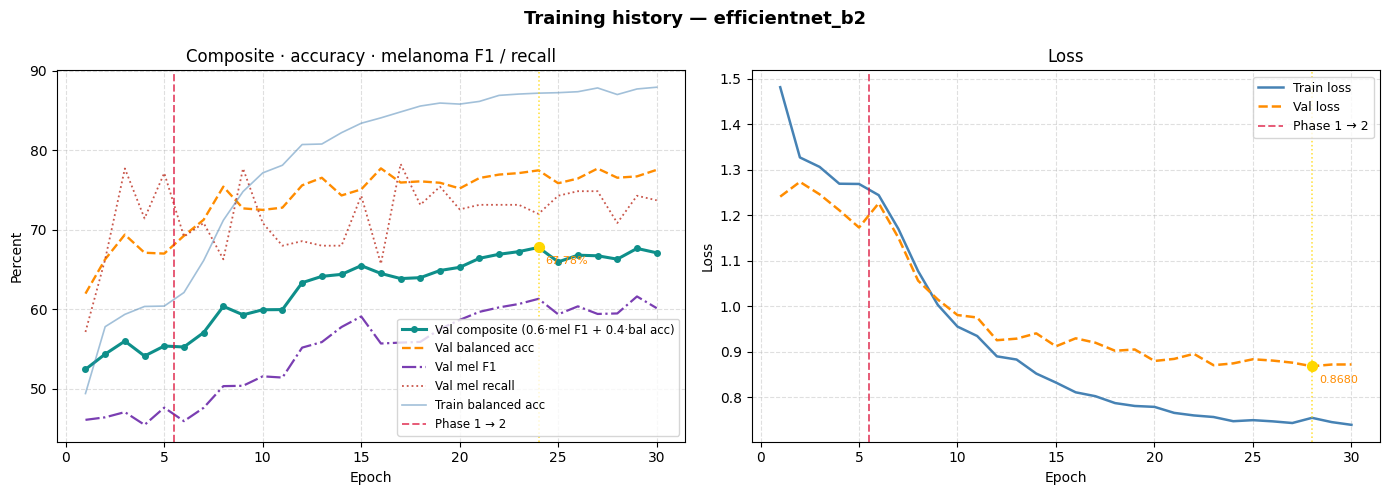

[efficientnet_b2] Best composite: 67.78 at epoch 24 | Min val loss: 0.8680 at epoch 28


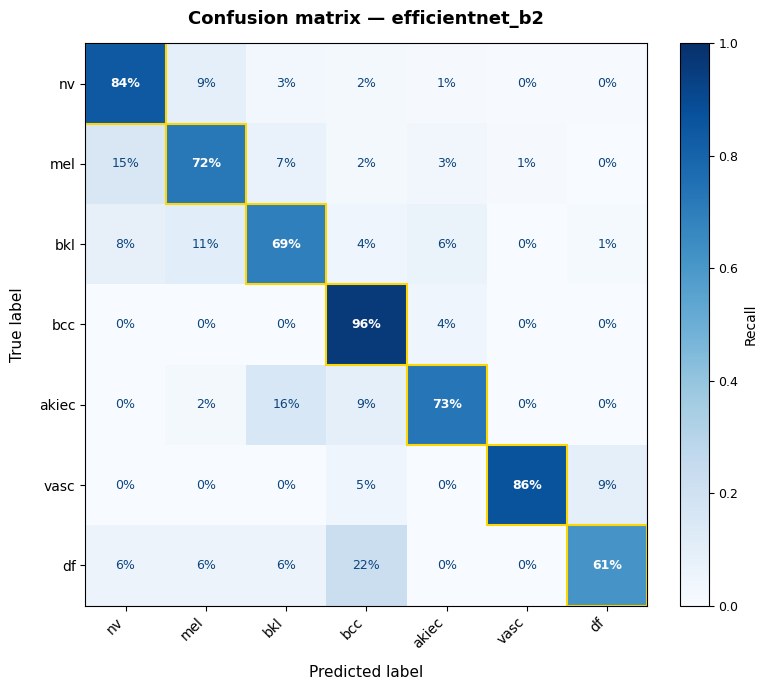

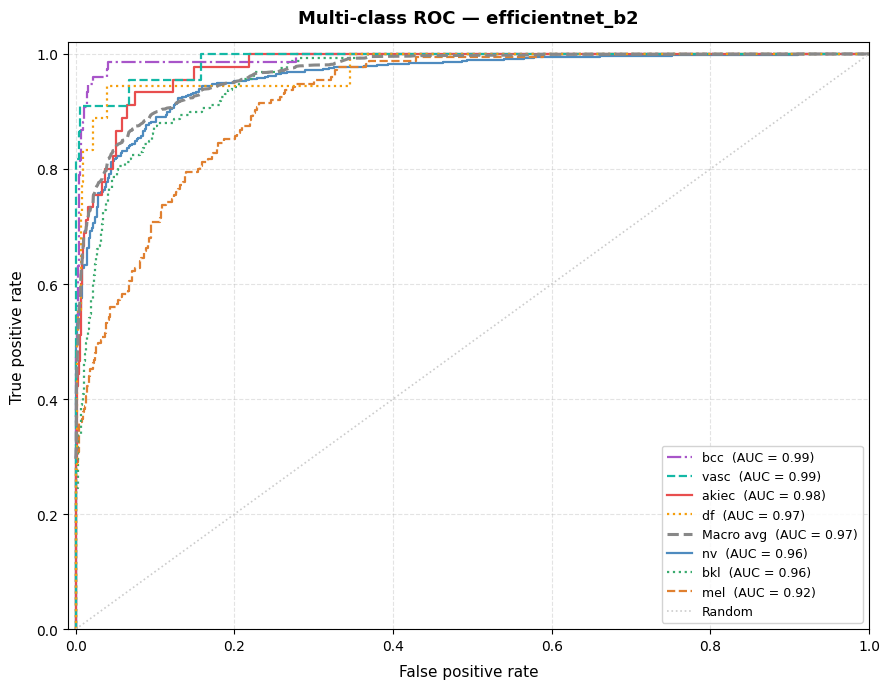


Classification report for efficientnet_b2:
              precision    recall  f1-score   support

          nv       0.95      0.84      0.90       982
         mel       0.53      0.72      0.61       175
         bkl       0.70      0.69      0.69       159
         bcc       0.66      0.96      0.78        76
       akiec       0.54      0.73      0.62        45
        vasc       0.76      0.86      0.81        22
          df       0.58      0.61      0.59        18

    accuracy                           0.81      1477
   macro avg       0.68      0.77      0.72      1477
weighted avg       0.84      0.81      0.82      1477

Balanced accuracy :  77.48%
Mel recall        :  72.00%
Mel precision     :  53.39%
Mel F1            :  61.31%
Composite         :  67.78  (0.6·mel F1 + 0.4·bal acc)

Starting comparison for: resnet50
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 194MB/s]



-------------------- Phase 1: head only --------------------


[resnet50 (Phase 1)] Epoch  1/5 | train loss 1.3923 bal_acc 54.29% | val loss 1.2866 bal_acc 63.06% mel(rec/prec/f1) 57.14/38.61/46.08% composite 52.87 ★ new best


[resnet50 (Phase 1)] Epoch  2/5 | train loss 1.2776 bal_acc 59.69% | val loss 1.3313 bal_acc 64.74% mel(rec/prec/f1) 39.43/43.40/41.32% composite 50.69


...

[resnet50 (Phase 2)] Epoch 21/25 | train loss 0.6182 bal_acc 93.88% | val loss 0.8712 bal_acc 75.59% mel(rec/prec/f1) 66.86/49.79/57.07% composite 64.48


[resnet50 (Phase 2)] Epoch 22/25 | train loss 0.6161 bal_acc 93.78% | val loss 0.8785 bal_acc 76.26% mel(rec/prec/f1) 72.57/48.11/57.86% composite 65.22


[resnet50 (Phase 2)] Epoch 23/25 | train loss 0.6125 bal_acc 93.77% | val loss 0.8721 bal_acc 76.46% mel(rec/prec/f1) 67.43/49.17/56.87% composite 64.70


[resnet50 (Phase 2)] Epoch 24/25 | train loss 0.6076 bal_acc 94.12% | val loss 0.8550 bal_acc 77.34% mel(rec/prec/f1) 63.43/50.45/56.20% composite 64.66


[resnet50 (Phase 2)] Epoch 25/25 | train loss 0.6082 bal_acc 93.91% | val loss 0.8616 bal_acc 76.07% mel(rec/prec/f1) 66.29/49.57/56.72% composite 64.46
[SUCCESS] resnet50 parameters saved to: /content/drive/MyDrive/skin_cancer_detection/models/best_resnet50.pth


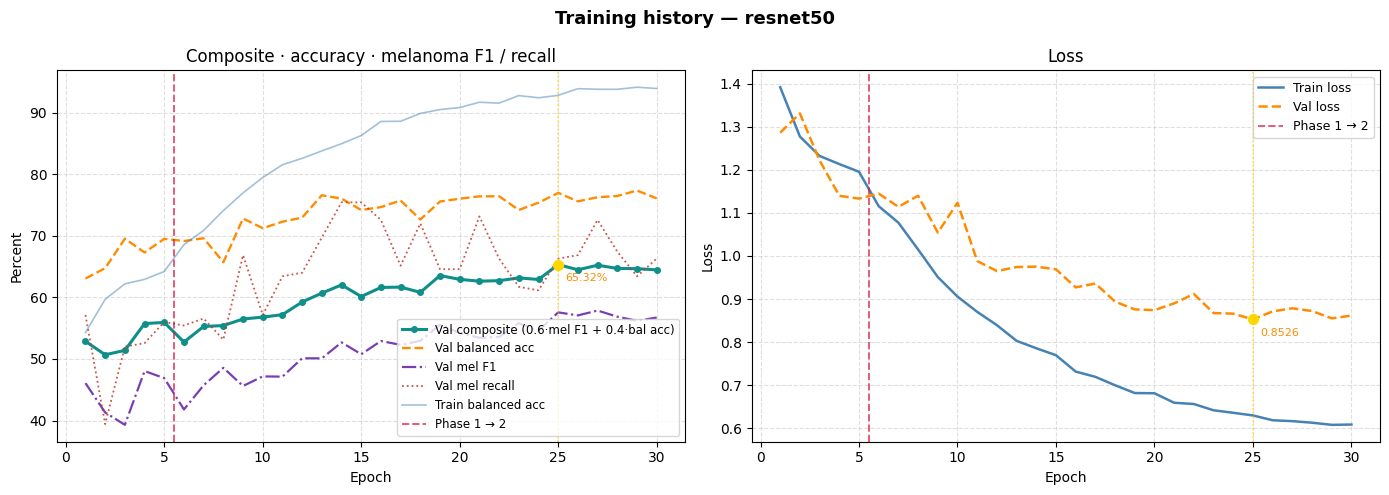

[resnet50] Best composite: 65.32 at epoch 25 | Min val loss: 0.8526 at epoch 25


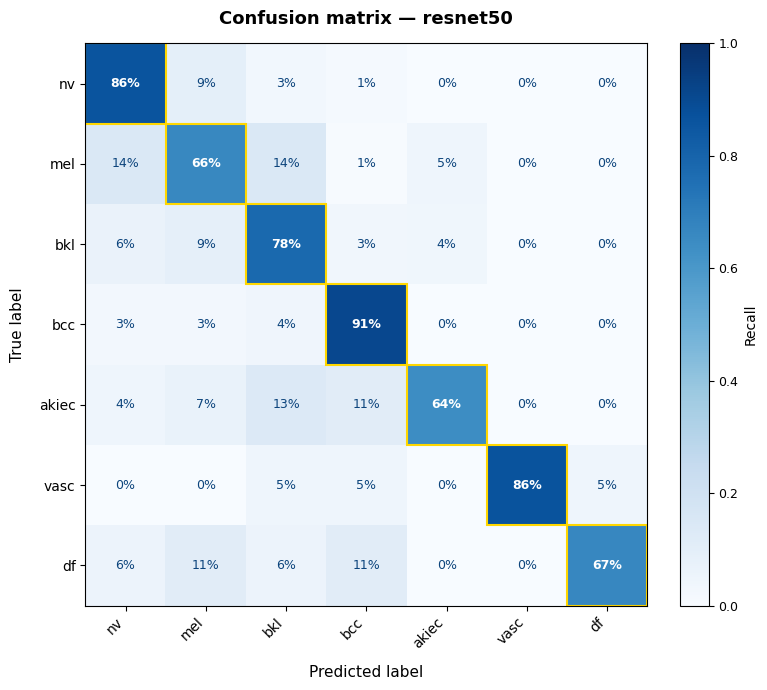

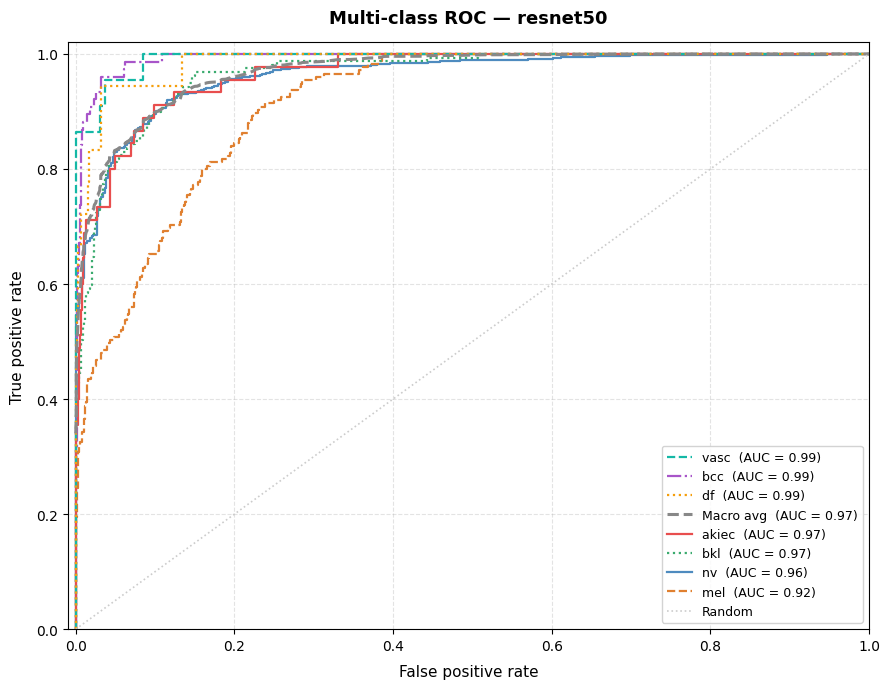


Classification report for resnet50:
              precision    recall  f1-score   support

          nv       0.95      0.86      0.91       982
         mel       0.51      0.66      0.58       175
         bkl       0.66      0.78      0.72       159
         bcc       0.73      0.91      0.81        76
       akiec       0.64      0.64      0.64        45
        vasc       0.90      0.86      0.88        22
          df       0.80      0.67      0.73        18

    accuracy                           0.82      1477
   macro avg       0.74      0.77      0.75      1477
weighted avg       0.85      0.82      0.83      1477

Balanced accuracy :  76.96%
Mel recall        :  66.29%
Mel precision     :  50.88%
Mel F1            :  57.57%
Composite         :  65.32  (0.6·mel F1 + 0.4·bal acc)

Starting comparison for: densenet169
Downloading: "https://download.pytorch.org/models/densenet169-b2777c0a.pth" to /root/.cache/torch/hub/checkpoints/densenet169-b2777c0a.pth


100%|██████████| 54.7M/54.7M [00:00<00:00, 167MB/s]



-------------------- Phase 1: head only --------------------


[densenet169 (Phase 1)] Epoch  1/5 | train loss 1.3443 bal_acc 56.69% | val loss 1.1802 bal_acc 63.78% mel(rec/prec/f1) 50.86/39.73/44.61% composite 52.28 ★ new best


[densenet169 (Phase 1)] Epoch  2/5 | train loss 1.1656 bal_acc 65.44% | val loss 1.1697 bal_acc 64.90% mel(rec/prec/f1) 66.86/38.61/48.95% composite 55.33 ★ new best


...

[densenet169 (Phase 2)] Epoch 19/25 | train loss 0.6642 bal_acc 92.46% | val loss 0.8646 bal_acc 74.38% mel(rec/prec/f1) 66.29/51.10/57.71% composite 64.38


[densenet169 (Phase 2)] Epoch 20/25 | train loss 0.6573 bal_acc 92.18% | val loss 0.8654 bal_acc 71.86% mel(rec/prec/f1) 70.29/47.13/56.42% composite 62.60


[densenet169 (Phase 2)] Epoch 21/25 | train loss 0.6542 bal_acc 92.92% | val loss 0.8767 bal_acc 73.59% mel(rec/prec/f1) 72.00/45.82/56.00% composite 63.04


[densenet169 (Phase 2)] Epoch 22/25 | train loss 0.6452 bal_acc 93.24% | val loss 0.8656 bal_acc 72.54% mel(rec/prec/f1) 69.71/47.47/56.48% composite 62.91


[densenet169 (Phase 2)] Epoch 23/25 | train loss 0.6487 bal_acc 93.02% | val loss 0.8589 bal_acc 73.10% mel(rec/prec/f1) 68.00/50.00/57.63% composite 63.82
Early stopping at epoch 23 (no improvement for 7 epochs)
[SUCCESS] densenet169 parameters saved to: /content/drive/MyDrive/skin_cancer_detection/models/best_densenet169.pth


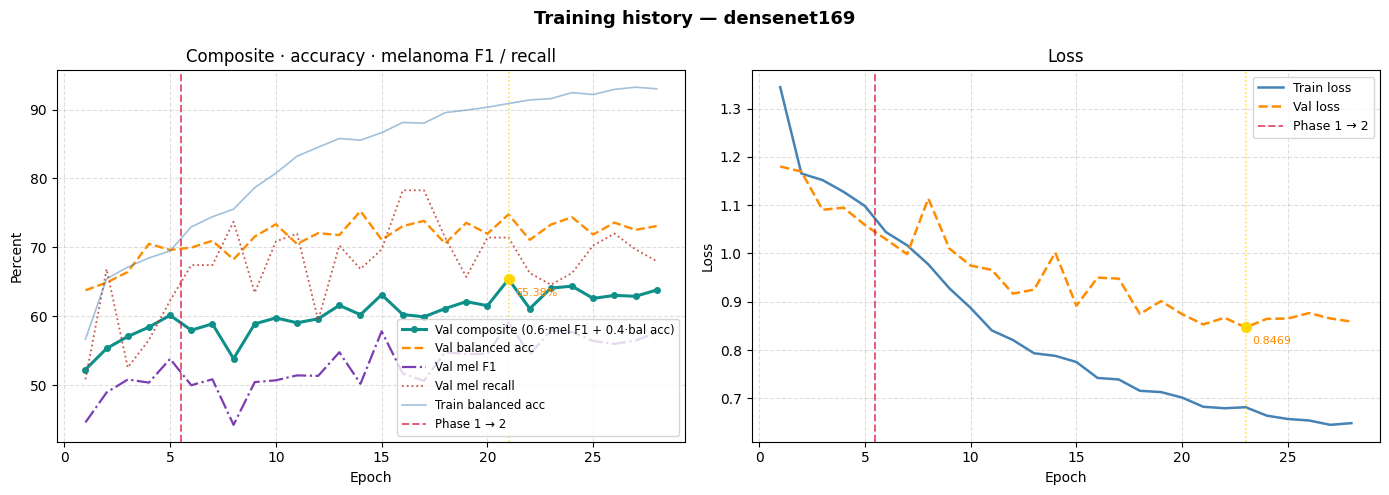

[densenet169] Best composite: 65.38 at epoch 21 | Min val loss: 0.8469 at epoch 23


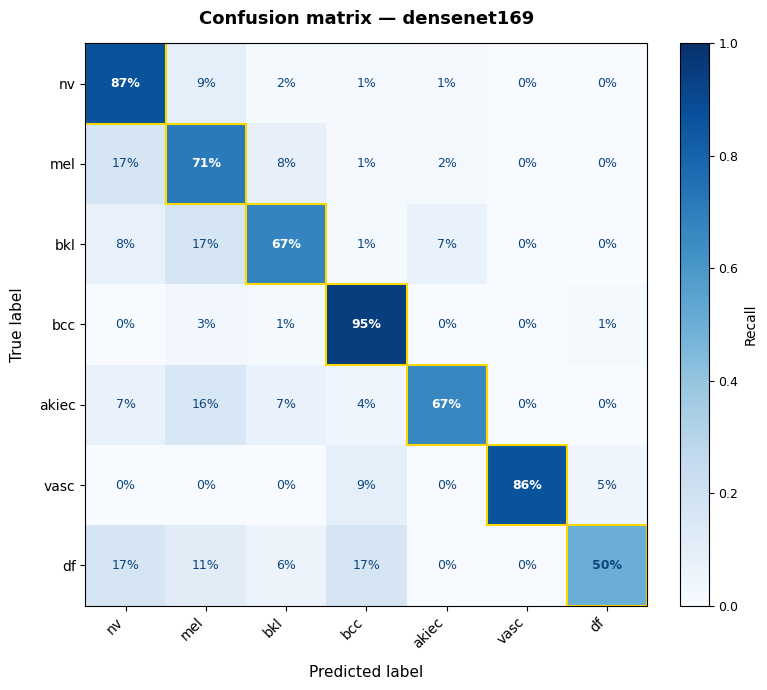

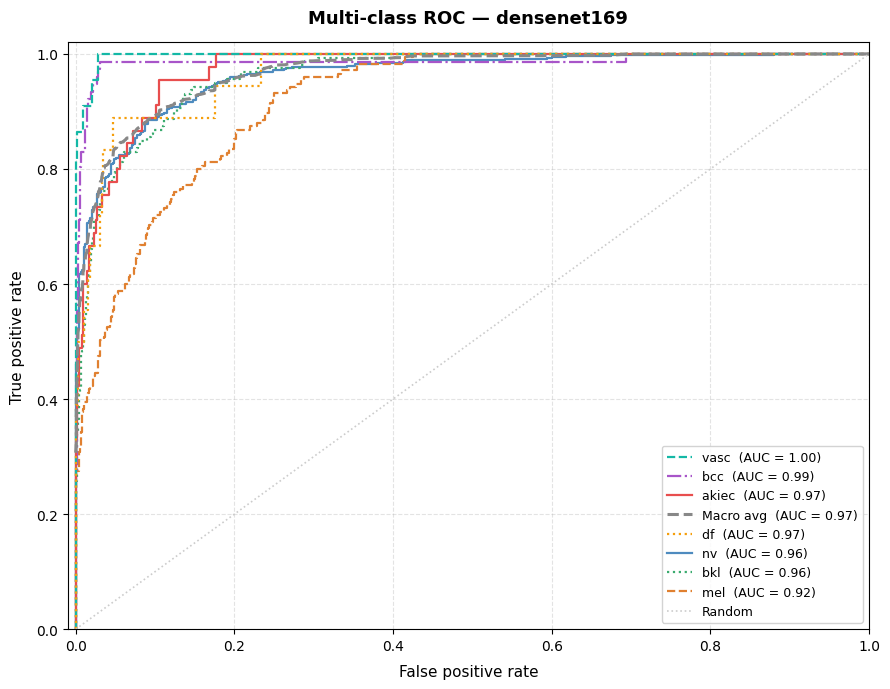


Classification report for densenet169:
              precision    recall  f1-score   support

          nv       0.95      0.87      0.91       982
         mel       0.50      0.71      0.59       175
         bkl       0.76      0.67      0.71       159
         bcc       0.74      0.95      0.83        76
       akiec       0.57      0.67      0.61        45
        vasc       0.90      0.86      0.88        22
          df       0.64      0.50      0.56        18

    accuracy                           0.82      1477
   macro avg       0.72      0.75      0.73      1477
weighted avg       0.85      0.82      0.83      1477

Balanced accuracy :  74.79%
Mel recall        :  71.43%
Mel precision     :  50.40%
Mel F1            :  59.10%
Composite         :  65.38  (0.6·mel F1 + 0.4·bal acc)

Starting comparison for: vgg16
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 241MB/s]



-------------------- Phase 1: head only --------------------


[vgg16 (Phase 1)] Epoch  1/5 | train loss 1.8012 bal_acc 29.93% | val loss 1.5354 bal_acc 38.53% mel(rec/prec/f1) 64.57/25.80/36.87% composite 37.53 ★ new best


[vgg16 (Phase 1)] Epoch  2/5 | train loss 1.7135 bal_acc 35.81% | val loss 1.5355 bal_acc 49.29% mel(rec/prec/f1) 32.00/38.10/34.78% composite 40.59 ★ new best


...

[vgg16 (Phase 2)] Epoch 13/25 | train loss 0.8186 bal_acc 83.42% | val loss 0.8921 bal_acc 75.17% mel(rec/prec/f1) 69.14/47.08/56.02% composite 63.68


[vgg16 (Phase 2)] Epoch 14/25 | train loss 0.8030 bal_acc 84.54% | val loss 0.8844 bal_acc 74.41% mel(rec/prec/f1) 65.14/50.67/57.00% composite 63.96


[vgg16 (Phase 2)] Epoch 15/25 | train loss 0.7973 bal_acc 84.29% | val loss 0.9148 bal_acc 75.94% mel(rec/prec/f1) 77.71/43.73/55.97% composite 63.95


[vgg16 (Phase 2)] Epoch 16/25 | train loss 0.7727 bal_acc 86.38% | val loss 0.8914 bal_acc 72.81% mel(rec/prec/f1) 69.71/46.56/55.84% composite 62.62


[vgg16 (Phase 2)] Epoch 17/25 | train loss 0.7816 bal_acc 85.49% | val loss 0.8956 bal_acc 71.58% mel(rec/prec/f1) 76.57/42.68/54.81% composite 61.52
Early stopping at epoch 17 (no improvement for 7 epochs)
[SUCCESS] vgg16 parameters saved to: /content/drive/MyDrive/skin_cancer_detection/models/best_vgg16.pth


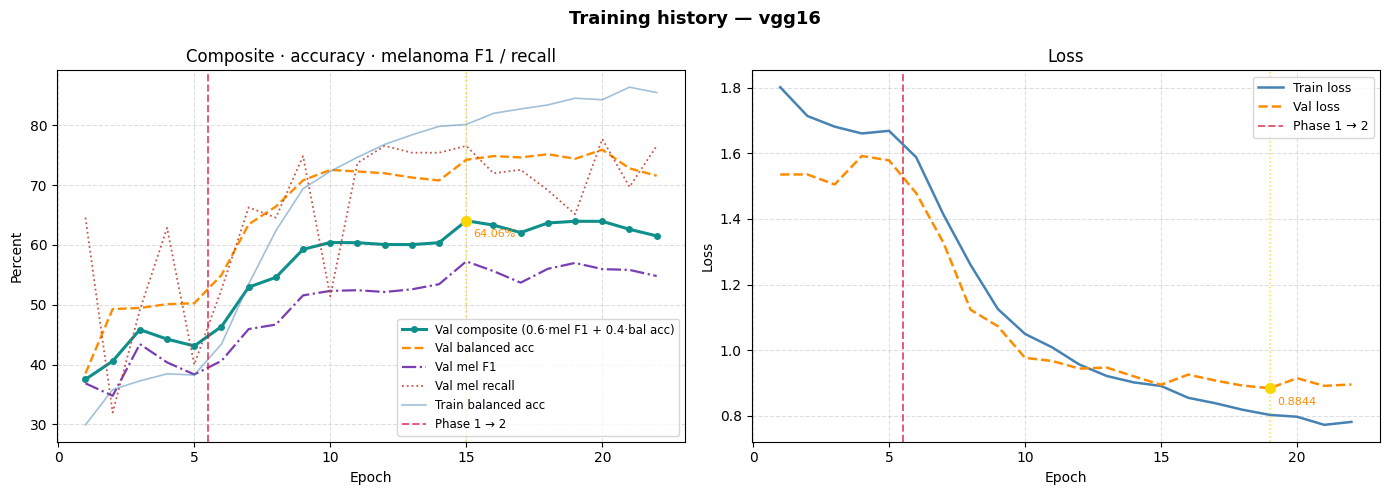

[vgg16] Best composite: 64.06 at epoch 15 | Min val loss: 0.8844 at epoch 19


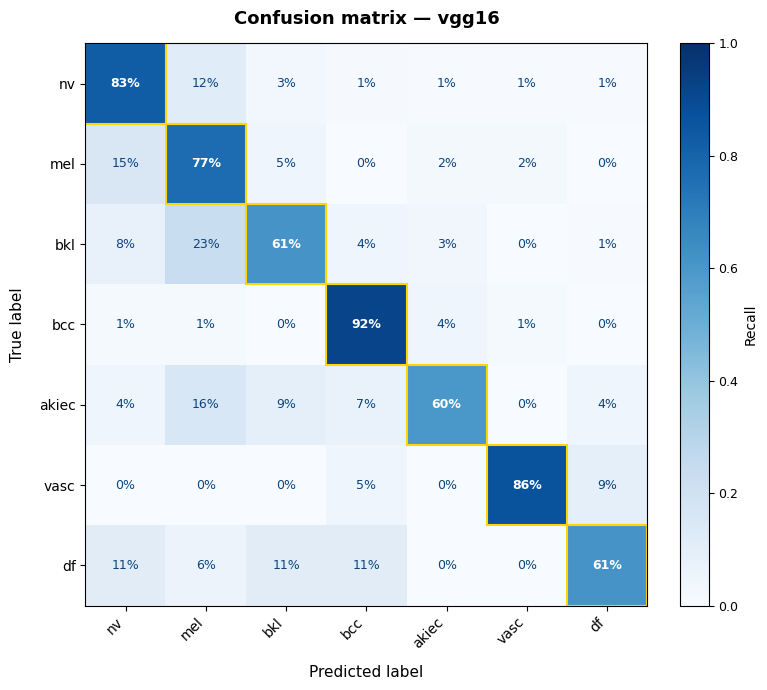

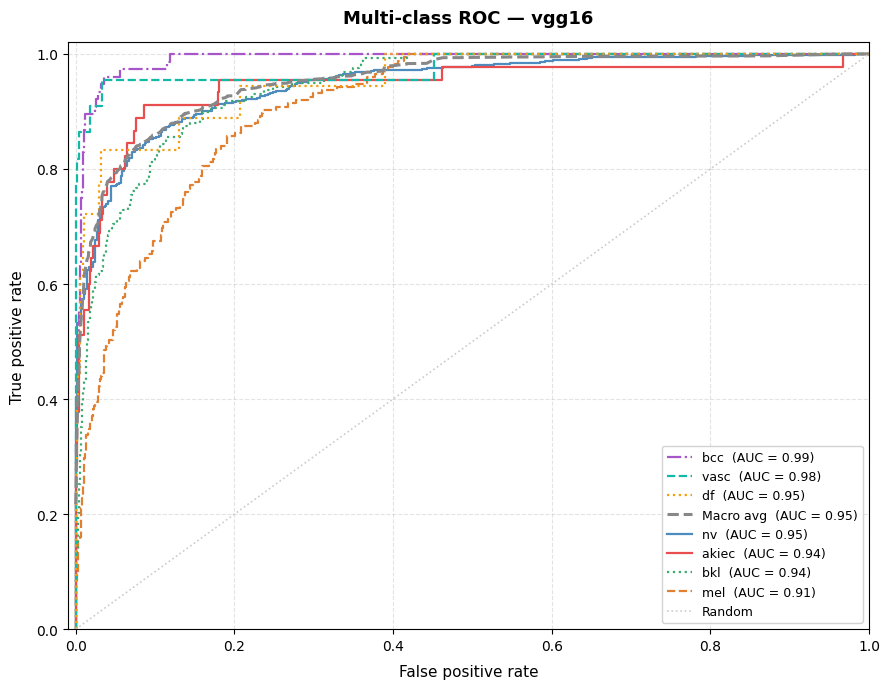


Classification report for vgg16:
              precision    recall  f1-score   support

          nv       0.95      0.83      0.88       982
         mel       0.46      0.77      0.57       175
         bkl       0.69      0.61      0.65       159
         bcc       0.76      0.92      0.83        76
       akiec       0.59      0.60      0.59        45
        vasc       0.68      0.86      0.76        22
          df       0.48      0.61      0.54        18

    accuracy                           0.79      1477
   macro avg       0.66      0.74      0.69      1477
weighted avg       0.83      0.79      0.80      1477

Balanced accuracy :  74.25%
Mel recall        :  76.57%
Mel precision     :  45.73%
Mel F1            :  57.26%
Composite         :  64.06  (0.6·mel F1 + 0.4·bal acc)


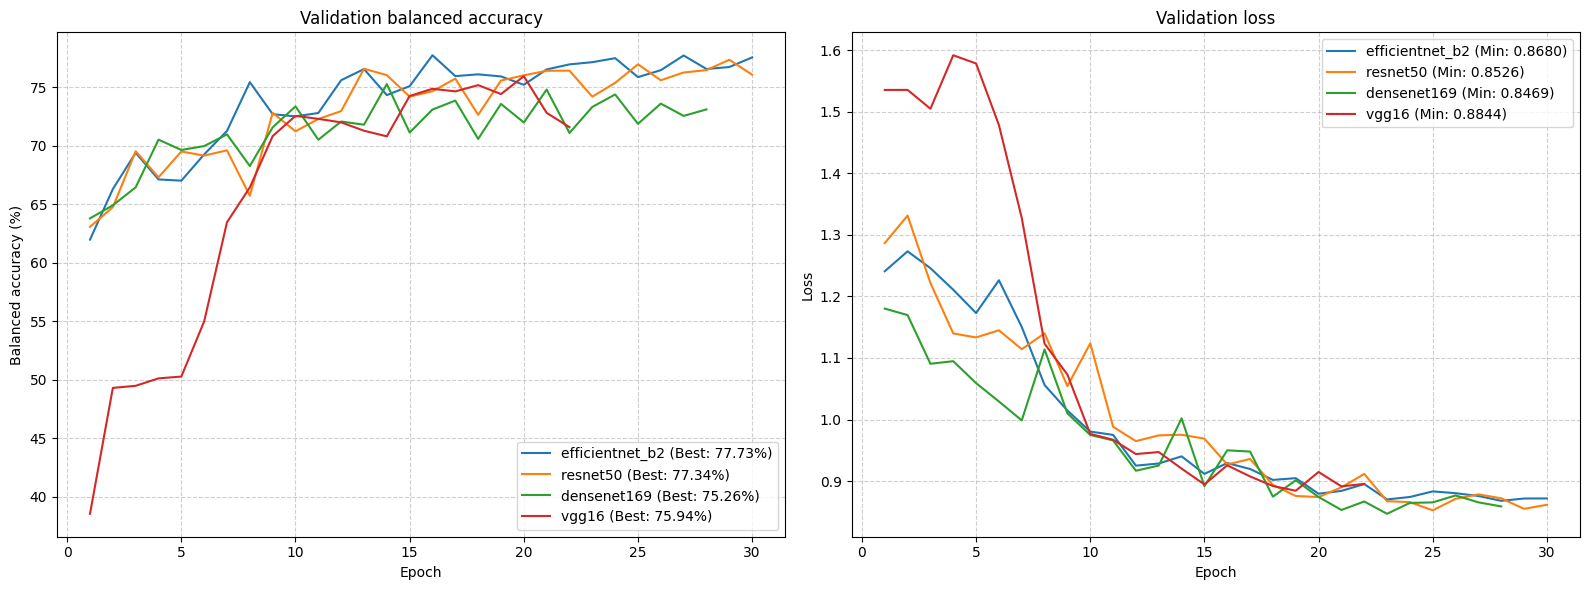

/tmp/ipykernel_3110/2806692263.py:203: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=f1_scores, palette='viridis')


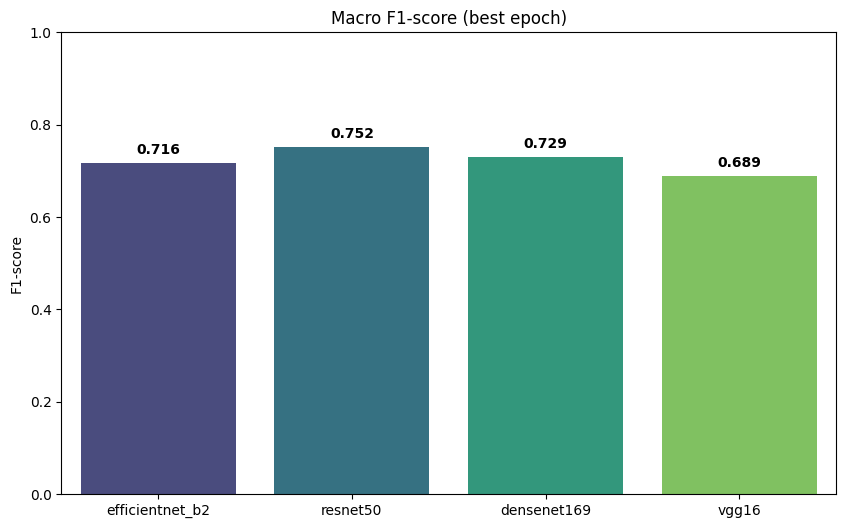


MODEL                  BAL ACC   MEL REC   MEL PREC    MEL F1   MACRO F1   COMPOSITE
--------------------------------------------------------------------------------------------
efficientnet_b2         77.48%    72.00%     53.39%    61.31%     71.61%      67.78 ◀ WINNER
densenet169             74.79%    71.43%     50.40%    59.10%     72.89%      65.38
resnet50                76.96%    66.29%     50.88%    57.57%     75.15%      65.32
vgg16                   74.25%    76.57%     45.73%    57.26%     68.94%      64.06

★ Winner: efficientnet_b2
  → Recommended upgrade: efficientnet_v2_s
  → Input resolution:    384 px
  → Rationale:           Same compound-scaling philosophy with the improved V2 training recipe.


In [23]:
model_list = ['efficientnet_b2', 'resnet50', 'densenet169', 'vgg16']
all_comparison_results = run_model_comparison(
    model_names=model_list,
    num_epochs=25,
    patience=7,
)
plot_cross_model_comparison(all_comparison_results)
winner_model = select_winner(all_comparison_results)

## Final training on the upgrade architecture

Trains the upgraded variant of the comparison winner using the advanced loop
(MixUp + EMA). Same two-phase structure as the comparison; Phase 2 budget is
expanded to give EMA room to settle.

In [24]:
def train_upgraded_winner(winner_name, num_epochs=45, patience=10,
                          n_tta_augmented=4, mixup_alpha=0.2):
    """Train the upgrade variant of the comparison winner.

    Phase 1 uses the standard (non-advanced) loop for head warmup. Phase 2
    uses the advanced loop with MixUp + EMA + linear warmup → cosine decay.
    Saves the best EMA-snapshot state_dict.

    Args:
        winner_name: Comparison winner key (e.g. 'efficientnet_b2').
        num_epochs: Phase 2 epoch budget.
        patience: Early-stopping patience on the composite metric.
        n_tta_augmented: Number of augmented TTA passes per validation epoch.
        mixup_alpha: Beta(α, α) shape parameter for MixUp.

    Returns:
        Tuple of (model, results_dict). The model is loaded with the best
        EMA weights; the dict carries history + best-epoch arrays for
        downstream reporting and calibration.
    """
    info = UPGRADE_MAP[winner_name]
    upgrade_name = info['upgrade_name']
    img_size = info['img_size']
    classes = list(CLASS_MAP.keys())

    print(f'\n{"=" * 66}')
    print(f'  Final training: {winner_name}  →  {upgrade_name}  ({img_size} px)')
    print(f'  Rationale: {info["rationale"]}')
    print(f'{"=" * 66}\n')

    model = info['init_fn'](len(classes))
    train_loader = DataLoader(
        MNIST_HAM_Dataset(train_df, transform=get_train_transforms(img_size)),
        batch_size=64, sampler=sampler,
        num_workers=8, pin_memory=True,
        persistent_workers=True, prefetch_factor=3,
    )
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # ── Phase 1: head only (no MixUp / EMA) ─────────────────────────
    print(f'{"-" * 20} Phase 1: head only {"-" * 20}')
    for p in model.parameters():
        p.requires_grad = False
    head_module_for_warmup = info['head_module_fn'](model)
    for p in head_module_for_warmup.parameters():
        p.requires_grad = True

    optimizer_p1 = torch.optim.AdamW(head_module_for_warmup.parameters(),
                                     lr=1e-3, weight_decay=5e-4)
    scheduler_p1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_p1, mode='max', factor=0.5, patience=2, min_lr=1e-6,
    )
    history_p1, _, _, _ = train_and_evaluate(
        model=model, train_loader=train_loader, val_df=val_df,
        img_size=img_size, criterion=criterion,
        optimizer=optimizer_p1, scheduler=scheduler_p1,
        num_epochs=5, model_name=f'{upgrade_name} (Phase 1)',
        patience=5, freeze_head_bn=False, n_tta_augmented=n_tta_augmented,
    )

    # ── Phase 2: full fine-tune (MixUp + EMA + warmup→cosine) ───────
    print(f'\n{"-" * 20} Phase 2: full fine-tune {"-" * 20}')
    for p in model.parameters():
        p.requires_grad = True

    head_module = info['head_module_fn'](model)
    head_params_list = list(head_module.parameters())
    head_param_ids = {id(p) for p in head_params_list}
    backbone_params_list = [p for p in model.parameters()
                            if id(p) not in head_param_ids]

    optimizer_p2 = torch.optim.AdamW(
        [{'params': backbone_params_list, 'lr': 2e-5},
         {'params': head_params_list,     'lr': 1e-4}],
        weight_decay=5e-4,
    )
    warmup_epochs = 2
    scheduler_p2 = torch.optim.lr_scheduler.SequentialLR(
        optimizer_p2,
        schedulers=[
            torch.optim.lr_scheduler.LinearLR(
                optimizer_p2, start_factor=0.1, total_iters=warmup_epochs),
            torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer_p2, T_max=num_epochs - warmup_epochs),
        ],
        milestones=[warmup_epochs],
    )

    history_p2, y_true, y_pred, y_probs = train_and_evaluate_advanced(
        model=model, train_loader=train_loader, val_df=val_df,
        img_size=img_size, criterion=criterion,
        optimizer=optimizer_p2, scheduler=scheduler_p2,
        num_epochs=num_epochs, model_name=f'{upgrade_name} (Phase 2)',
        patience=patience, freeze_head_bn=True,
        n_tta_augmented=n_tta_augmented,
        mixup_alpha=mixup_alpha, mixup_prob=0.8,
        mixup_disable_last=max(5, num_epochs // 4),
        use_ema=True, ema_decay=0.999,
    )

    save_model_to_drive(model.state_dict(), upgrade_name)

    combined_history = {k: history_p1[k] + history_p2[k] for k in history_p1}
    phase1_len = len(history_p1['train_balanced_acc'])
    plot_training_history(combined_history, model_name=upgrade_name,
                          phase_boundary=phase1_len)
    plot_confusion_matrix(y_true, y_pred, classes=classes, model_name=upgrade_name)
    plot_auc_roc(y_true, y_probs, classes=classes, model_name=upgrade_name)

    bal_acc = balanced_accuracy_score(y_true, y_pred) * 100
    mel_recall = recall_score(y_true, y_pred, labels=[1],
                              average=None, zero_division=0)[0] * 100
    mel_precision = precision_score(y_true, y_pred, labels=[1],
                                    average=None, zero_division=0)[0] * 100
    mel_f1 = f1_score(y_true, y_pred, labels=[1],
                      average=None, zero_division=0)[0] * 100
    report = classification_report(y_true, y_pred, target_names=classes,
                                   output_dict=True, zero_division=0)
    macro_f1 = report['macro avg']['f1-score'] * 100
    composite = 0.6 * mel_f1 + 0.4 * bal_acc

    print(f'\nClassification report — {upgrade_name} (validation):')
    print(classification_report(y_true, y_pred, target_names=classes,
                                zero_division=0))
    print('\n' + '=' * 64)
    print(f'  FINAL VALIDATION METRICS — {upgrade_name}')
    print('-' * 64)
    print(f'  Balanced accuracy : {bal_acc:6.2f}%')
    print(f'  Mel recall        : {mel_recall:6.2f}%')
    print(f'  Mel precision     : {mel_precision:6.2f}%')
    print(f'  Mel F1            : {mel_f1:6.2f}%')
    print(f'  Macro F1          : {macro_f1:6.2f}%')
    print(f'  Composite         : {composite:6.2f}  (0.6·mel F1 + 0.4·bal acc)')
    print('=' * 64)

    return model, {
        'upgrade_name':  upgrade_name,
        'img_size':      img_size,
        'history':       combined_history,
        'y_true':        y_true,
        'y_pred':        y_pred,
        'y_probs':       y_probs,
        'val_metrics':   {'bal_acc': bal_acc, 'mel_recall': mel_recall,
                          'mel_precision': mel_precision, 'mel_f1': mel_f1,
                          'macro_f1': macro_f1, 'composite': composite},
    }

### Run the upgrade training


  Final training: efficientnet_b2  →  efficientnet_v2_s  (384 px)
  Rationale: Same compound-scaling philosophy with the improved V2 training recipe.

-------------------- Phase 1: head only --------------------


[efficientnet_v2_s (Phase 1)] Epoch  1/5 | train loss 1.5658 bal_acc 47.87% | val loss 1.2906 bal_acc 60.99% mel(rec/prec/f1) 58.86/35.15/44.02% composite 50.80 ★ new best


[efficientnet_v2_s (Phase 1)] Epoch  2/5 | train loss 1.3498 bal_acc 56.76% | val loss 1.2137 bal_acc 61.48% mel(rec/prec/f1) 70.29/34.65/46.42% composite 52.44 ★ new best


[efficientnet_v2_s (Phase 1)] Epoch  3/5 | train loss 1.3138 bal_acc 58.37% | val loss 1.1988 bal_acc 66.05% mel(rec/prec/f1) 63.43/37.76/47.33% composite 54.82 ★ new best


[efficientnet_v2_s (Phase 1)] Epoch  4/5 | train loss 1.3059 bal_acc 59.15% | val loss 1.1800 bal_acc 62.49% mel(rec/prec/f1) 53.71/41.05/46.53% composite 52.92


...

[efficientnet_v2_s (Phase 2)] Epoch 41/45 | train loss 0.5749 bal_acc 94.83% | val loss 0.7604 bal_acc 80.14% mel(rec/prec/f1) 68.57/63.16/65.75% composite 71.51


[efficientnet_v2_s (Phase 2)] Epoch 42/45 | train loss 0.5697 bal_acc 95.55% | val loss 0.7603 bal_acc 80.97% mel(rec/prec/f1) 70.86/66.67/68.70% composite 73.61 ★ new best


[efficientnet_v2_s (Phase 2)] Epoch 43/45 | train loss 0.5718 bal_acc 95.35% | val loss 0.7598 bal_acc 79.88% mel(rec/prec/f1) 66.86/64.29/65.55% composite 71.28


[efficientnet_v2_s (Phase 2)] Epoch 44/45 | train loss 0.5682 bal_acc 95.44% | val loss 0.7595 bal_acc 80.28% mel(rec/prec/f1) 68.00/64.32/66.11% composite 71.78


[efficientnet_v2_s (Phase 2)] Epoch 45/45 | train loss 0.5643 bal_acc 95.82% | val loss 0.7589 bal_acc 80.63% mel(rec/prec/f1) 69.14/66.12/67.60% composite 72.81
[SUCCESS] efficientnet_v2_s parameters saved to: /content/drive/MyDrive/skin_cancer_detection/models/best_efficientnet_v2_s.pth


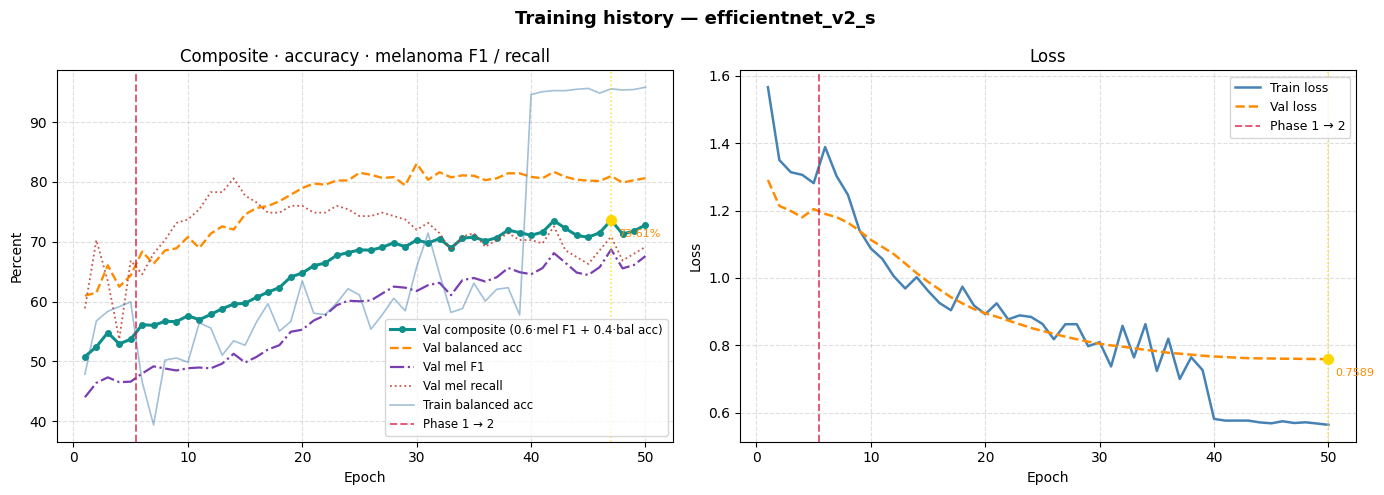

[efficientnet_v2_s] Best composite: 73.61 at epoch 47 | Min val loss: 0.7589 at epoch 50


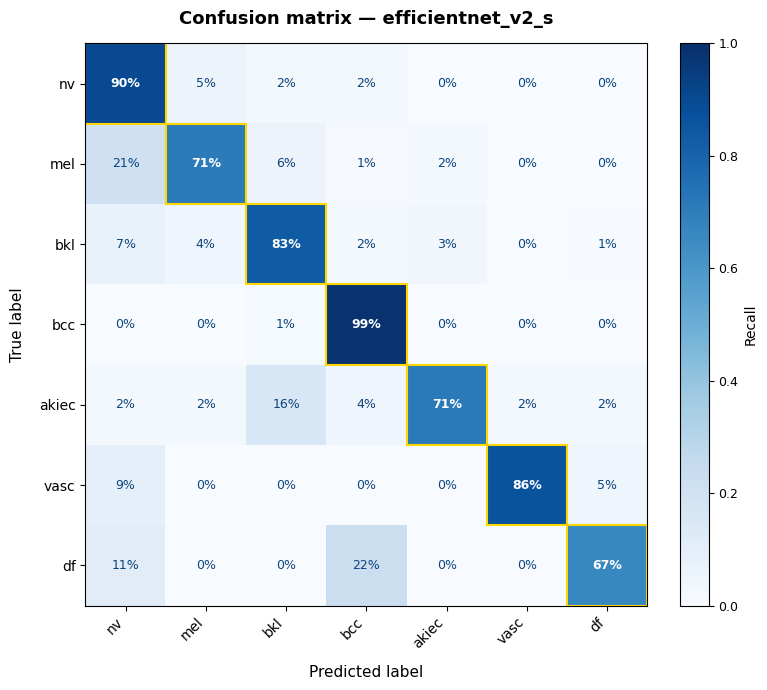

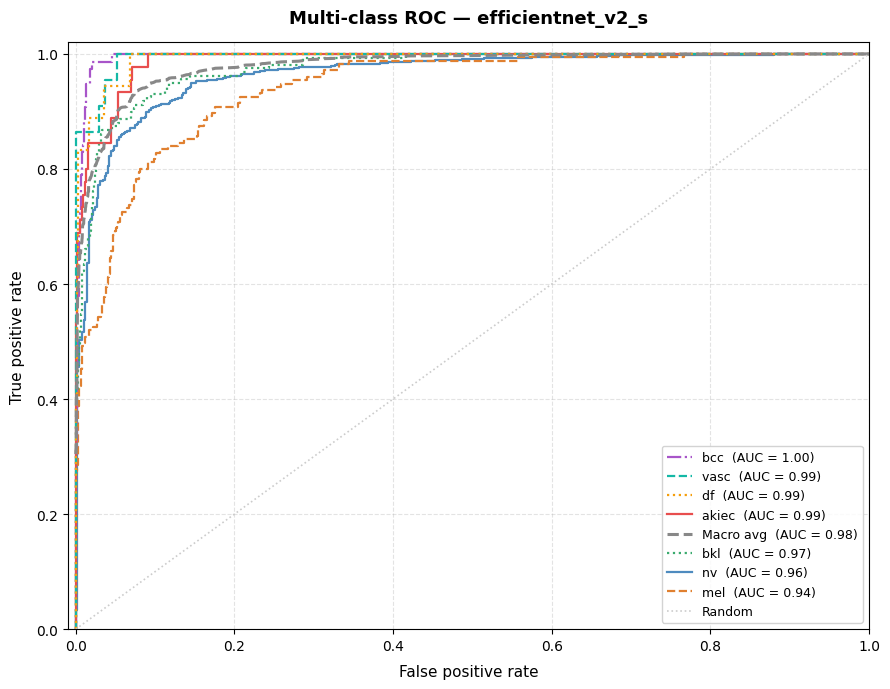


Classification report — efficientnet_v2_s (validation):
              precision    recall  f1-score   support

          nv       0.94      0.90      0.92       982
         mel       0.67      0.71      0.69       175
         bkl       0.77      0.83      0.80       159
         bcc       0.73      0.99      0.84        76
       akiec       0.78      0.71      0.74        45
        vasc       0.86      0.86      0.86        22
          df       0.75      0.67      0.71        18

    accuracy                           0.87      1477
   macro avg       0.79      0.81      0.79      1477
weighted avg       0.87      0.87      0.87      1477


  FINAL VALIDATION METRICS — efficientnet_v2_s
----------------------------------------------------------------
  Balanced accuracy :  80.97%
  Mel recall        :  70.86%
  Mel precision     :  66.67%
  Mel F1            :  68.70%
  Macro F1          :  79.41%
  Composite         :  73.61  (0.6·mel F1 + 0.4·bal acc)


In [26]:
final_model, final_results = train_upgraded_winner(
    winner_name=winner_model,
    num_epochs=45,
    patience=10,
    n_tta_augmented=8,
    mixup_alpha=0.2,
)

## Temperature calibration

A single positive scalar `T` is fit on the validation set such that the
softmax of `logits / T` minimises NLL. Argmax-preserving — every
classification metric is unchanged; only the magnitudes of the displayed
probabilities shift, so the confidence number becomes an honest probability.

In [27]:
class TemperatureScaler(nn.Module):
    """Single positive scalar `T` parametrised as `exp(log_T)`."""

    def __init__(self):
        super().__init__()
        self.log_T = nn.Parameter(torch.zeros(1))

    @property
    def T(self):
        return self.log_T.exp()

    def forward(self, logits):
        return logits / self.T


@torch.no_grad()
def _collect_clean_logits(model, df, img_size, batch_size=64):
    """Run one clean center-crop pass and return logits + labels on device.

    Uses fp32 (no AMP) so the fitted temperature isn't influenced by
    autocast rounding behaviour.
    """
    model.eval()
    clean_t = get_val_transforms(img_size)
    loader = DataLoader(MNIST_HAM_Dataset(df, transform=clean_t),
                        batch_size=batch_size, shuffle=False)
    logits_all, labels_all = [], []
    for x, y in tqdm(loader, desc='Collecting val logits', leave=False):
        logits_all.append(model(x.to(device, non_blocking=True)).float())
        labels_all.append(y)
    return torch.cat(logits_all), torch.cat(labels_all).to(device)


def _ece(probs, labels, n_bins=15):
    """Expected Calibration Error over equal-width bins on max-prob confidence."""
    conf, pred = probs.max(dim=1)
    correct = pred.eq(labels).float()
    edges = torch.linspace(0, 1, n_bins + 1, device=probs.device)
    ece = 0.0
    for i in range(n_bins):
        in_bin = (conf > edges[i]) & (conf <= edges[i + 1])
        prop = in_bin.float().mean().item()
        if prop > 0:
            ece += abs(conf[in_bin].mean().item() - correct[in_bin].mean().item()) * prop
    return ece


def _reliability_diagram(probs_before, probs_after, labels, model_name, T, n_bins=15):
    """Two-panel reliability + confidence distribution plot, before vs after."""
    def bin_stats(probs):
        conf, pred = probs.max(dim=1)
        correct = pred.eq(labels).float()
        edges = torch.linspace(0, 1, n_bins + 1, device=probs.device)
        mids = ((edges[:-1] + edges[1:]) / 2).cpu().numpy()
        accs = np.zeros(n_bins); counts = np.zeros(n_bins)
        for i in range(n_bins):
            in_bin = (conf > edges[i]) & (conf <= edges[i + 1])
            n = in_bin.float().sum().item()
            counts[i] = n
            if n > 0:
                accs[i] = correct[in_bin].mean().item()
        return accs, counts, mids

    acc_b, cnt_b, mids = bin_stats(probs_before)
    acc_a, cnt_a, _ = bin_stats(probs_after)
    w = (1.0 / n_bins) * 0.9

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'Calibration — {model_name}  (T = {T:.3f})',
                 fontsize=13, fontweight='bold')

    ax1.bar(mids - w / 4, acc_b, width=w / 2, color='#c0392b',
            alpha=0.75, label='Before (raw softmax)',
            edgecolor='#6f1f15', linewidth=0.4)
    ax1.bar(mids + w / 4, acc_a, width=w / 2, color='#0e8f8a',
            alpha=0.85, label='After (calibrated)',
            edgecolor='#063f3c', linewidth=0.4)
    ax1.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.55,
             label='Perfect calibration')
    ax1.set_xlabel('Predicted confidence')
    ax1.set_ylabel('Empirical accuracy')
    ax1.set_title('Reliability diagram')
    ax1.set_xlim(0, 1); ax1.set_ylim(0, 1); ax1.set_aspect('equal')
    ax1.legend(loc='upper left', fontsize=9)
    ax1.grid(True, ls='--', alpha=0.4)

    ax2.bar(mids - w / 4, cnt_b, width=w / 2, color='#c0392b',
            alpha=0.65, label='Before')
    ax2.bar(mids + w / 4, cnt_a, width=w / 2, color='#0e8f8a',
            alpha=0.85, label='After')
    ax2.set_xlabel('Predicted confidence')
    ax2.set_ylabel('# val samples')
    ax2.set_title('Confidence distribution')
    ax2.legend(loc='upper left', fontsize=9)
    ax2.grid(True, ls='--', alpha=0.4)

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


def calibrate(model, df, img_size, model_name,
              save_dir='/content/drive/MyDrive/skin_cancer_detection/models'):
    """Fit a single temperature on val, render the reliability diagram, save T.

    Returns the fitted temperature scalar. Persists it to a JSON file under
    the project's Drive folder so the Flask app can pick it up.
    """
    print(f'[calibration] Collecting val logits for {model_name}...')
    logits, labels = _collect_clean_logits(model, df, img_size)

    scaler = TemperatureScaler().to(device)
    optimizer = torch.optim.LBFGS([scaler.log_T], lr=0.05, max_iter=200)
    criterion = nn.CrossEntropyLoss()

    def closure():
        optimizer.zero_grad()
        loss = criterion(scaler(logits), labels)
        loss.backward()
        return loss

    optimizer.step(closure)
    T = scaler.T.item()

    probs_before = F.softmax(logits, dim=1)
    probs_after  = F.softmax(logits / T, dim=1)
    ece_before = _ece(probs_before, labels) * 100
    ece_after  = _ece(probs_after, labels) * 100

    print('\n' + '=' * 60)
    print(f'  CALIBRATION — {model_name}')
    print('-' * 60)
    print(f'  Temperature T : {T:.4f}')
    print(f'  ECE  before   : {ece_before:5.2f}%')
    print(f'  ECE  after    : {ece_after:5.2f}%   (lower is better; <5% is good)')
    print('=' * 60)

    _reliability_diagram(probs_before, probs_after, labels, model_name, T)

    os.makedirs(save_dir, exist_ok=True)
    json_path = os.path.join(save_dir, f'temperature_{model_name}.json')
    with open(json_path, 'w') as f:
        json.dump({
            'model_name':  model_name,
            'temperature': float(T),
            'ece_before':  float(ece_before),
            'ece_after':   float(ece_after),
        }, f, indent=2)
    print(f'\n[SUCCESS] Temperature saved to: {json_path}')
    return T

### Run the calibration step

[calibration] Collecting val logits for efficientnet_v2_s...



  CALIBRATION — efficientnet_v2_s
------------------------------------------------------------
  Temperature T : 0.8722
  ECE  before   :  4.01%
  ECE  after    :  2.37%   (lower is better; <5% is good)


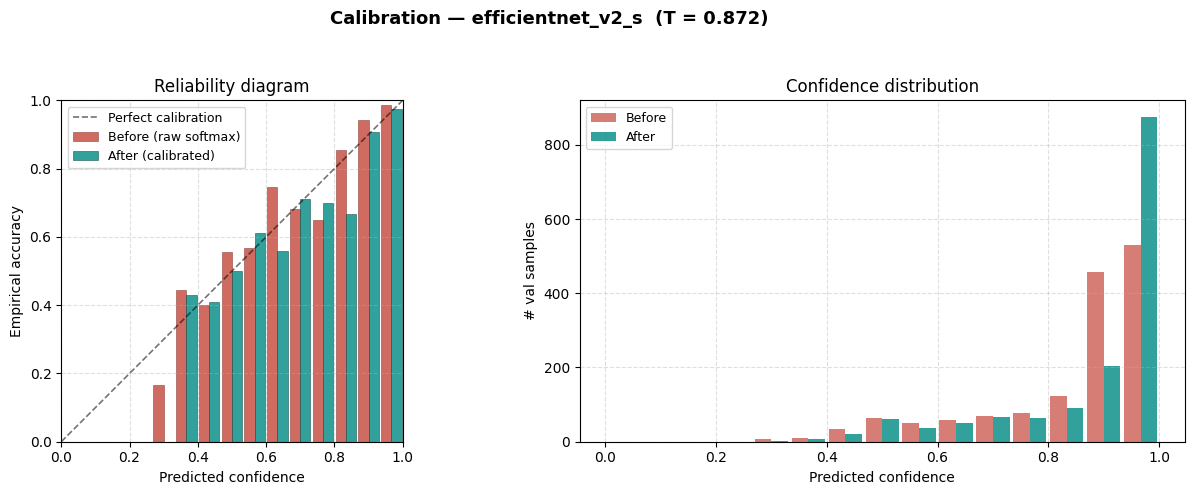


[SUCCESS] Temperature saved to: /content/drive/MyDrive/skin_cancer_detection/models/temperature_efficientnet_v2_s.json


In [28]:
TEMPERATURE = calibrate(
    model      = final_model,
    df         = val_df,
    img_size   = final_results['img_size'],
    model_name = final_results['upgrade_name'],
)

## Held-out test-set evaluation

Final reporting on `test_df`. The test set was never used for early stopping,
calibration, threshold tuning or architecture selection — the numbers below
are the genuinely unbiased generalisation estimates and the ones to cite in
the project writeup.

Uses the calibrated probabilities (logits divided by the fitted temperature
before softmax) so the confidence values shown match the calibrated model
that would be served by the Flask app.

In [29]:
def evaluate_on_test(model, df, img_size, temperature, model_name,
                     n_augmented=8):
    """Run TTA on the test set with calibrated probabilities and produce
    the final classification report, confusion matrix and ROC curves.

    Args:
        model: The fully-trained, EMA-snapshotted model loaded with best weights.
        df: The held-out test dataframe.
        img_size: Input resolution.
        temperature: Calibration temperature fitted on val.
        model_name: Used in plot titles and console output.
        n_augmented: TTA passes — 8 for the final report keeps noise low.

    Returns:
        Dict with the test-set metrics for reference.
    """
    classes = list(CLASS_MAP.keys())
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    _, amp_dtype, _ = _setup_amp()

    print(f'[test eval] Running calibrated TTA on {len(df)} test images...')
    _, y_true, y_pred, y_probs = tta_validate(
        model, df, img_size, criterion,
        n_augmented=n_augmented, use_amp=True, amp_dtype=amp_dtype,
        temperature=temperature, desc=f'{model_name} [test]',
    )

    bal_acc = balanced_accuracy_score(y_true, y_pred) * 100
    mel_recall = recall_score(y_true, y_pred, labels=[1],
                              average=None, zero_division=0)[0] * 100
    mel_precision = precision_score(y_true, y_pred, labels=[1],
                                    average=None, zero_division=0)[0] * 100
    mel_f1 = f1_score(y_true, y_pred, labels=[1],
                      average=None, zero_division=0)[0] * 100
    report = classification_report(y_true, y_pred, target_names=classes,
                                   output_dict=True, zero_division=0)
    macro_f1 = report['macro avg']['f1-score'] * 100
    composite = 0.6 * mel_f1 + 0.4 * bal_acc

    # Per-class ECE on the test set (top-1 calibration).
    probs_t = torch.tensor(y_probs)
    labels_t = torch.tensor(y_true)
    ece = _ece(probs_t, labels_t) * 100

    print(f'\nClassification report on TEST — {model_name}:')
    print(classification_report(y_true, y_pred, target_names=classes,
                                zero_division=0))

    plot_confusion_matrix(y_true, y_pred, classes=classes,
                          model_name=f'{model_name} (test)')
    plot_auc_roc(y_true, y_probs, classes=classes,
                 model_name=f'{model_name} (test)')

    print('\n' + '=' * 64)
    print(f'  HELD-OUT TEST METRICS — {model_name}')
    print('-' * 64)
    print(f'  Test set size       : {len(df)}')
    print(f'  Balanced accuracy   : {bal_acc:6.2f}%')
    print(f'  Mel recall          : {mel_recall:6.2f}%')
    print(f'  Mel precision       : {mel_precision:6.2f}%')
    print(f'  Mel F1              : {mel_f1:6.2f}%')
    print(f'  Macro F1            : {macro_f1:6.2f}%')
    print(f'  Composite (0.6·F1)  : {composite:6.2f}')
    print(f'  ECE (calibrated)    : {ece:5.2f}%')
    print('=' * 64)
    print(f'\nPaste into skin_cancer_app/config.py:')
    print(f"  WINNER_MODEL                 = '{model_name}'")
    print(f"  WEIGHTS_PATH                 = './models/best_{model_name}.pth'")
    print(f"  TEMPERATURE                  = {temperature:.4f}")
    print(f"  MODEL_INFO['Architecture']   = '{model_name} · fine-tuned ConvNet'")
    print(f"  MODEL_INFO['Top-1 accuracy'] = "
          f"'{bal_acc:.1f}% bal · {mel_f1:.1f}% mel F1 · {mel_precision:.1f}% mel prec (test)'")

    return {
        'y_true':       y_true,
        'y_pred':       y_pred,
        'y_probs':      y_probs,
        'bal_acc':      bal_acc,
        'mel_recall':   mel_recall,
        'mel_precision':mel_precision,
        'mel_f1':       mel_f1,
        'macro_f1':     macro_f1,
        'composite':    composite,
        'ece':          ece,
    }

### Run the test evaluation

[test eval] Running calibrated TTA on 1516 test images...



Classification report on TEST — efficientnet_v2_s:
              precision    recall  f1-score   support

          nv       0.96      0.87      0.91      1020
         mel       0.55      0.71      0.62       168
         bkl       0.67      0.70      0.69       162
         bcc       0.71      0.83      0.77        78
       akiec       0.51      0.68      0.58        47
        vasc       0.58      0.86      0.69        21
          df       0.67      0.60      0.63        20

    accuracy                           0.82      1516
   macro avg       0.66      0.75      0.70      1516
weighted avg       0.85      0.82      0.83      1516



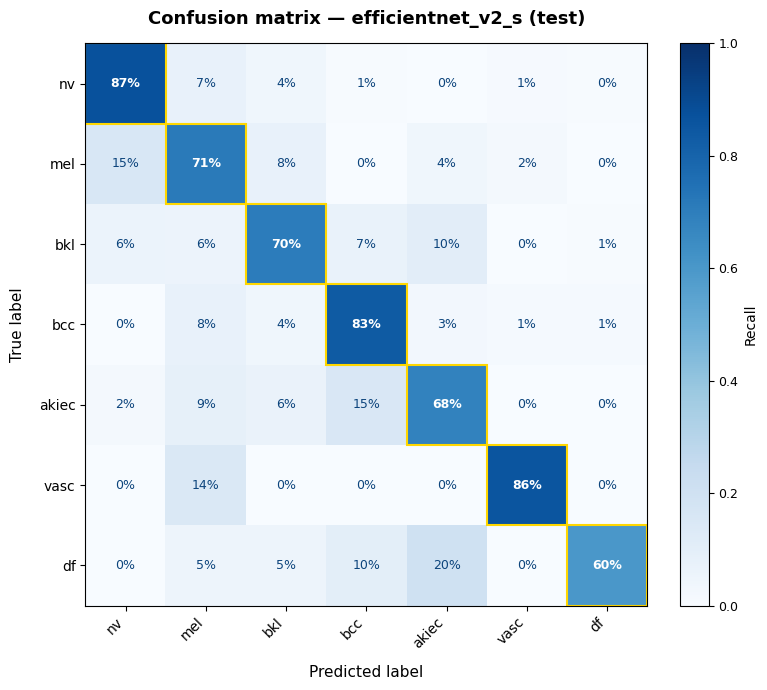

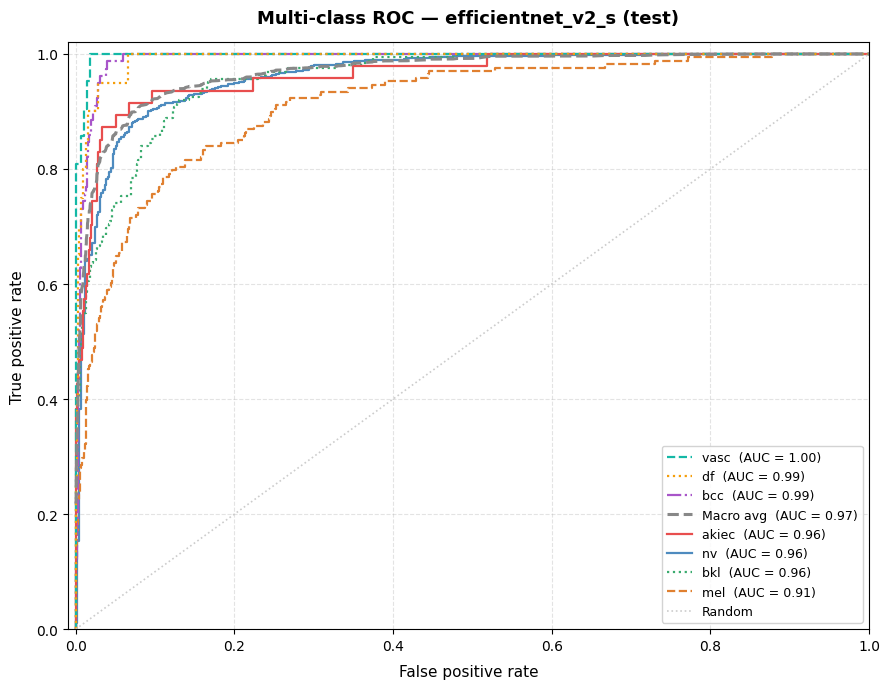


  HELD-OUT TEST METRICS — efficientnet_v2_s
----------------------------------------------------------------
  Test set size       : 1516
  Balanced accuracy   :  75.16%
  Mel recall          :  71.43%
  Mel precision       :  55.30%
  Mel F1              :  62.34%
  Macro F1            :  69.98%
  Composite (0.6·F1)  :  67.46
  ECE (calibrated)    :  2.98%

Paste into skin_cancer_app/config.py:
  WINNER_MODEL                 = 'efficientnet_v2_s'
  WEIGHTS_PATH                 = './models/best_efficientnet_v2_s.pth'
  TEMPERATURE                  = 0.8722
  MODEL_INFO['Architecture']   = 'efficientnet_v2_s · fine-tuned ConvNet'
  MODEL_INFO['Top-1 accuracy'] = '75.2% bal · 62.3% mel F1 · 55.3% mel prec (test)'


In [30]:
test_metrics = evaluate_on_test(
    model        = final_model,
    df           = test_df,
    img_size     = final_results['img_size'],
    temperature  = TEMPERATURE,
    model_name   = final_results['upgrade_name'],
    n_augmented  = 8,
)